# 🌌 Aurora Activity — XGBoost & Random Forest Prediction

**Models:** XGBoost · Random Forest · LightGBM · Extra Trees · Gradient Boosting

**Targets:** Kp Mean · Aurora Probability · Storm Level Classification

**Features:** Kp1–Kp8 (3-hourly), ap1–ap8, Ap, SN (sunspot number), F10.7 solar flux + engineered lag/rolling features

**Outputs:**
- `outputs/data/` — CSVs: metrics, forecasts, feature importance, predictions vs actuals
- `outputs/plots/` — All figures: loss curves, predictions, feature importance, residuals
- `outputs/models/` — Saved model files (.pkl) and scalers
- `outputs/reports/` — Full comparison report vs LSTM baselines


## 1. Setup & Dependencies

In [1]:
# ── Mount Google Drive ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted ✓')

Mounted at /content/drive
Google Drive mounted ✓


In [2]:
# ── Install dependencies ───────────────────────────────────────────────────────
!pip install xgboost lightgbm scikit-learn matplotlib pandas numpy seaborn shap joblib tqdm -q
print('Dependencies installed ✓')

Dependencies installed ✓


In [3]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import shap
from datetime import datetime, timedelta
from pathlib import Path
from tqdm import tqdm

# Sklearn
from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV

# Boosting
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
})

print('Imports loaded ✓')
print(f'XGBoost version: {xgb.__version__}')
print(f'LightGBM version: {lgb.__version__}')

Imports loaded ✓
XGBoost version: 3.2.0
LightGBM version: 4.6.0


## 2. Configuration

In [4]:
# ── Global configuration ───────────────────────────────────────────────────────

# *** Point this to your single data file ***
FILE_PATH = "/content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/1year.txt"

# Derived paths
DATA_DIR = str(__import__('pathlib').Path(FILE_PATH).parent)  # kept for output folder naming

# Lag features: how many past days to include as direct input columns
LAG_DAYS        = 14       # 2 weeks of lag features
ROLLING_WINDOWS = [3, 7, 14, 30]  # rolling stat windows (days)

# Forecast
FORECAST_DAYS   = 30       # days ahead to forecast

# Train/test split
TEST_SPLIT      = 0.15
VAL_SPLIT       = 0.15

# Aurora storm thresholds (Kp scale 0-9)
AURORA_KP_THRESHOLD = 5.0   # G1 storm → visible ~60°N
STORM_LEVELS = {
    'Quiet':   (0.0, 3.0),
    'Active':  (3.0, 5.0),
    'G1':      (5.0, 6.0),
    'G2':      (6.0, 7.0),
    'G3+':     (7.0, 10.0),
}

# Target column to predict
TARGET_COL = 'Kp_mean'

# Random seed
SEED = 42

# Model colours for plots
MODEL_COLORS = {
    'XGBoost':             '#f59e0b',
    'LightGBM':            '#10b981',
    'Random Forest':       '#3b82f6',
    'Extra Trees':         '#8b5cf6',
    'Gradient Boosting':   '#ef4444',
    'Actual':              '#1e293b',
}

print('Configuration loaded ✓')
print(f'File : {FILE_PATH}')
print(f'Target: {TARGET_COL}  |  Lags: {LAG_DAYS}d  |  Forecast: {FORECAST_DAYS}d')


Configuration loaded ✓
File : /content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/1year.txt
Target: Kp_mean  |  Lags: 14d  |  Forecast: 30d


In [5]:
# ── Output directory structure ─────────────────────────────────────────────────
_base = Path(DATA_DIR).parent
OUT_ROOT    = _base / 'xgb_rf_outputs'
OUT_DATA    = OUT_ROOT / 'data'
OUT_PLOTS   = OUT_ROOT / 'plots'
OUT_MODELS  = OUT_ROOT / 'models'
OUT_REPORTS = OUT_ROOT / 'reports'

for d in [OUT_DATA, OUT_PLOTS, OUT_MODELS, OUT_REPORTS]:
    d.mkdir(parents=True, exist_ok=True)

print('Output directories created:')
for d in [OUT_DATA, OUT_PLOTS, OUT_MODELS, OUT_REPORTS]:
    print(f'  {d}')

Output directories created:
  /content/drive/MyDrive/NewAuroraDataset/RealData/xgb_rf_outputs/data
  /content/drive/MyDrive/NewAuroraDataset/RealData/xgb_rf_outputs/plots
  /content/drive/MyDrive/NewAuroraDataset/RealData/xgb_rf_outputs/models
  /content/drive/MyDrive/NewAuroraDataset/RealData/xgb_rf_outputs/reports


## 3. Data Loading & Parsing

In [6]:
# ── GFZ Kp file parser — matched to actual file format ────────────────────────
# Format (from file header):
# YYYY MM DD  days  days_m  Bsr  dB  Kp1..8  ap1..8  Ap  SN  F10.7obs  F10.7adj  D
# col idx:  0    1   2     3      4     5    6   7..14  15..22  23  24    25        26  27

def parse_kp_file(filepath):
    rows = []
    skipped = 0
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            # Need at least: YYYY MM DD days days_m Bsr dB + 8 Kp + 8 ap + Ap = 27 cols
            if len(parts) < 24:
                skipped += 1
                continue
            try:
                year, month, day = int(parts[0]), int(parts[1]), int(parts[2])
                # parts[3]=days  parts[4]=days_m  parts[5]=Bsr  parts[6]=dB
                # Kp slots start at index 7
                kp_vals  = [float(parts[7  + i]) for i in range(8)]
                ap_vals  = [float(parts[15 + i]) for i in range(8)]
                Ap       = float(parts[23]) if len(parts) > 23 else float('nan')
                SN       = float(parts[24]) if len(parts) > 24 else float('nan')
                F107obs  = float(parts[25]) if len(parts) > 25 else float('nan')
                F107adj  = float(parts[26]) if len(parts) > 26 else float('nan')

                from datetime import datetime as _dt
                row = {'date': _dt(year, month, day)}
                for i, v in enumerate(kp_vals, 1): row[f'Kp{i}'] = v
                for i, v in enumerate(ap_vals, 1): row[f'ap{i}'] = v
                row.update({'Ap': Ap, 'SN': SN, 'F107obs': F107obs, 'F107adj': F107adj})
                rows.append(row)
            except (ValueError, IndexError):
                skipped += 1
                continue

    if not rows:
        raise ValueError(f'Parser read 0 rows from {filepath}. Skipped {skipped} lines.')

    df_out = (
        pd.DataFrame(rows)
        .sort_values('date')
        .drop_duplicates('date')
        .reset_index(drop=True)
    )
    print(f'Parsed {len(df_out):,} rows  |  skipped {skipped} lines')
    return df_out


# ── Load the single file ────────────────────────────────────────────────────────
print(f'Loading: {FILE_PATH}')
df_raw = parse_kp_file(FILE_PATH)

print(f'\nLoaded {len(df_raw):,} daily records')
print(f'Date range: {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'Columns ({len(df_raw.columns)}): {list(df_raw.columns)}')
df_raw.head(3)


Loading: /content/drive/MyDrive/NewAuroraDataset/RealData/GeomagneticData/1year.txt
Parsed 411 rows  |  skipped 0 lines

Loaded 411 daily records
Date range: 2025-01-01 → 2026-02-15
Columns (21): ['date', 'Kp1', 'Kp2', 'Kp3', 'Kp4', 'Kp5', 'Kp6', 'Kp7', 'Kp8', 'ap1', 'ap2', 'ap3', 'ap4', 'ap5', 'ap6', 'ap7', 'ap8', 'Ap', 'SN', 'F107obs', 'F107adj']


,date,Kp1,Kp2,Kp3,Kp4,Kp5,Kp6,Kp7,Kp8,ap1,...,ap3,ap4,ap5,ap6,ap7,ap8,Ap,SN,F107obs,F107adj
0,2025-01-01,4.000,5.333,5.000,6.000,6.667,8.000,6.333,4.000,27.0,...,48.0,80.0,111.0,207.0,94.0,27.0,81.0,198.0,219.2,211.9
1,2025-01-02,3.333,2.000,3.333,4.667,4.333,3.667,3.333,3.000,18.0,...,18.0,39.0,32.0,22.0,18.0,15.0,21.0,187.0,212.4,205.4
2,2025-01-03,3.000,3.333,3.333,2.000,0.667,1.333,1.000,1.667,15.0,...,18.0,7.0,3.0,5.0,4.0,6.0,10.0,199.0,199.9,193.3


## 4. Feature Engineering

In [7]:
# ── Core domain features (same as LSTM notebook) ──────────────────────────────
def engineer_base_features(df):
    df = df.copy()
    kp_cols = [f'Kp{i}' for i in range(1, 9)]
    ap_cols = [f'ap{i}' for i in range(1, 9)]

    # Clean missing values
    for col in kp_cols + ap_cols + ['Ap', 'SN', 'F107obs', 'F107adj']:
        df[col] = df[col].replace(-1, np.nan).replace(-1.0, np.nan)

    # Daily Kp stats
    df['Kp_mean']  = df[kp_cols].mean(axis=1)
    df['Kp_max']   = df[kp_cols].max(axis=1)
    df['Kp_min']   = df[kp_cols].min(axis=1)
    df['Kp_std']   = df[kp_cols].std(axis=1)
    df['Kp_range'] = df['Kp_max'] - df['Kp_min']
    df['Kp_skew']  = df[kp_cols].skew(axis=1)

    # Daily ap stats
    df['ap_mean']  = df[ap_cols].mean(axis=1)
    df['ap_max']   = df[ap_cols].max(axis=1)
    df['ap_sum']   = df[ap_cols].sum(axis=1)

    # Storm hours: 3-hour Kp slots >= threshold
    df['storm_hours'] = (df[kp_cols] >= AURORA_KP_THRESHOLD).sum(axis=1) * 3

    # Aurora binary label
    df['aurora_event'] = (df['Kp_max'] >= AURORA_KP_THRESHOLD).astype(int)

    # Storm level label
    def kp_to_level(kp):
        if kp >= 7:   return 'G3+'
        elif kp >= 6: return 'G2'
        elif kp >= 5: return 'G1'
        elif kp >= 3: return 'Active'
        else:         return 'Quiet'
    df['storm_level'] = df['Kp_max'].apply(kp_to_level)

    # Solar proxies
    df['F107_smooth'] = df['F107obs'].rolling(27, min_periods=1).mean()  # 27-day solar rotation
    df['SN_smooth']   = df['SN'].rolling(27, min_periods=1).mean()

    # Calendar features (seasonal/diurnal patterns)
    df['day_of_year']    = df['date'].dt.dayofyear
    df['month']          = df['date'].dt.month
    df['year']           = df['date'].dt.year
    df['season_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['season_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

    # Equinox proximity (aurora peaks near Mar/Sep equinoxes)
    doy = df['day_of_year']
    df['equinox_prox']   = np.minimum(
        np.abs(doy - 80),   # ~Mar 21
        np.abs(doy - 266)   # ~Sep 23
    )
    df['equinox_weight'] = np.exp(-df['equinox_prox'] / 20)

    # Solar cycle phase (approx 11-year = 4018 days)
    df['solar_cycle_phase'] = (df['day_of_year'] + (df['year'] * 365.25)) % 4018 / 4018
    df['solar_phase_sin']   = np.sin(2 * np.pi * df['solar_cycle_phase'])
    df['solar_phase_cos']   = np.cos(2 * np.pi * df['solar_cycle_phase'])

    return df


# ── Lag & rolling features (tree models need these explicitly) ─────────────────
def engineer_lag_features(df, lag_days=LAG_DAYS, rolling_windows=ROLLING_WINDOWS):
    """
    Unlike LSTMs, tree models cannot learn sequence order.
    We explicitly encode past N days as input features.
    """
    df = df.copy().sort_values('date').reset_index(drop=True)
    lag_targets = ['Kp_mean', 'Kp_max', 'ap_mean', 'ap_sum',
                   'storm_hours', 'aurora_event', 'F107obs', 'SN']

    # Lag features: t-1, t-2, ..., t-lag_days
    for col in lag_targets:
        for lag in range(1, lag_days + 1):
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    # Rolling statistics: mean, max, std
    for col in ['Kp_mean', 'Kp_max', 'ap_sum', 'storm_hours']:
        for w in rolling_windows:
            df[f'{col}_roll{w}mean'] = df[col].shift(1).rolling(w, min_periods=1).mean()
            df[f'{col}_roll{w}max']  = df[col].shift(1).rolling(w, min_periods=1).max()
            df[f'{col}_roll{w}std']  = df[col].shift(1).rolling(w, min_periods=1).std()

    # Trend: day-over-day change in Kp
    df['Kp_delta1']  = df['Kp_mean'].diff(1)
    df['Kp_delta3']  = df['Kp_mean'].diff(3)
    df['Kp_delta7']  = df['Kp_mean'].diff(7)

    # Cumulative storm energy (last 7 days)
    df['storm_energy_7d'] = df['ap_sum'].shift(1).rolling(7, min_periods=1).sum()

    return df


# ── Apply all feature engineering ──────────────────────────────────────────────
print('Engineering features...')
df = engineer_base_features(df_raw)
df = engineer_lag_features(df)

# Drop rows with NaN from lag creation
df = df.dropna().reset_index(drop=True)

print(f'Feature-engineered dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range after lag drop: {df["date"].min().date()} → {df["date"].max().date()}')

Engineering features...
Feature-engineered dataset: 377 rows × 209 columns
Date range after lag drop: 2025-01-15 → 2026-02-15


## 5. EDA — Quick Overview

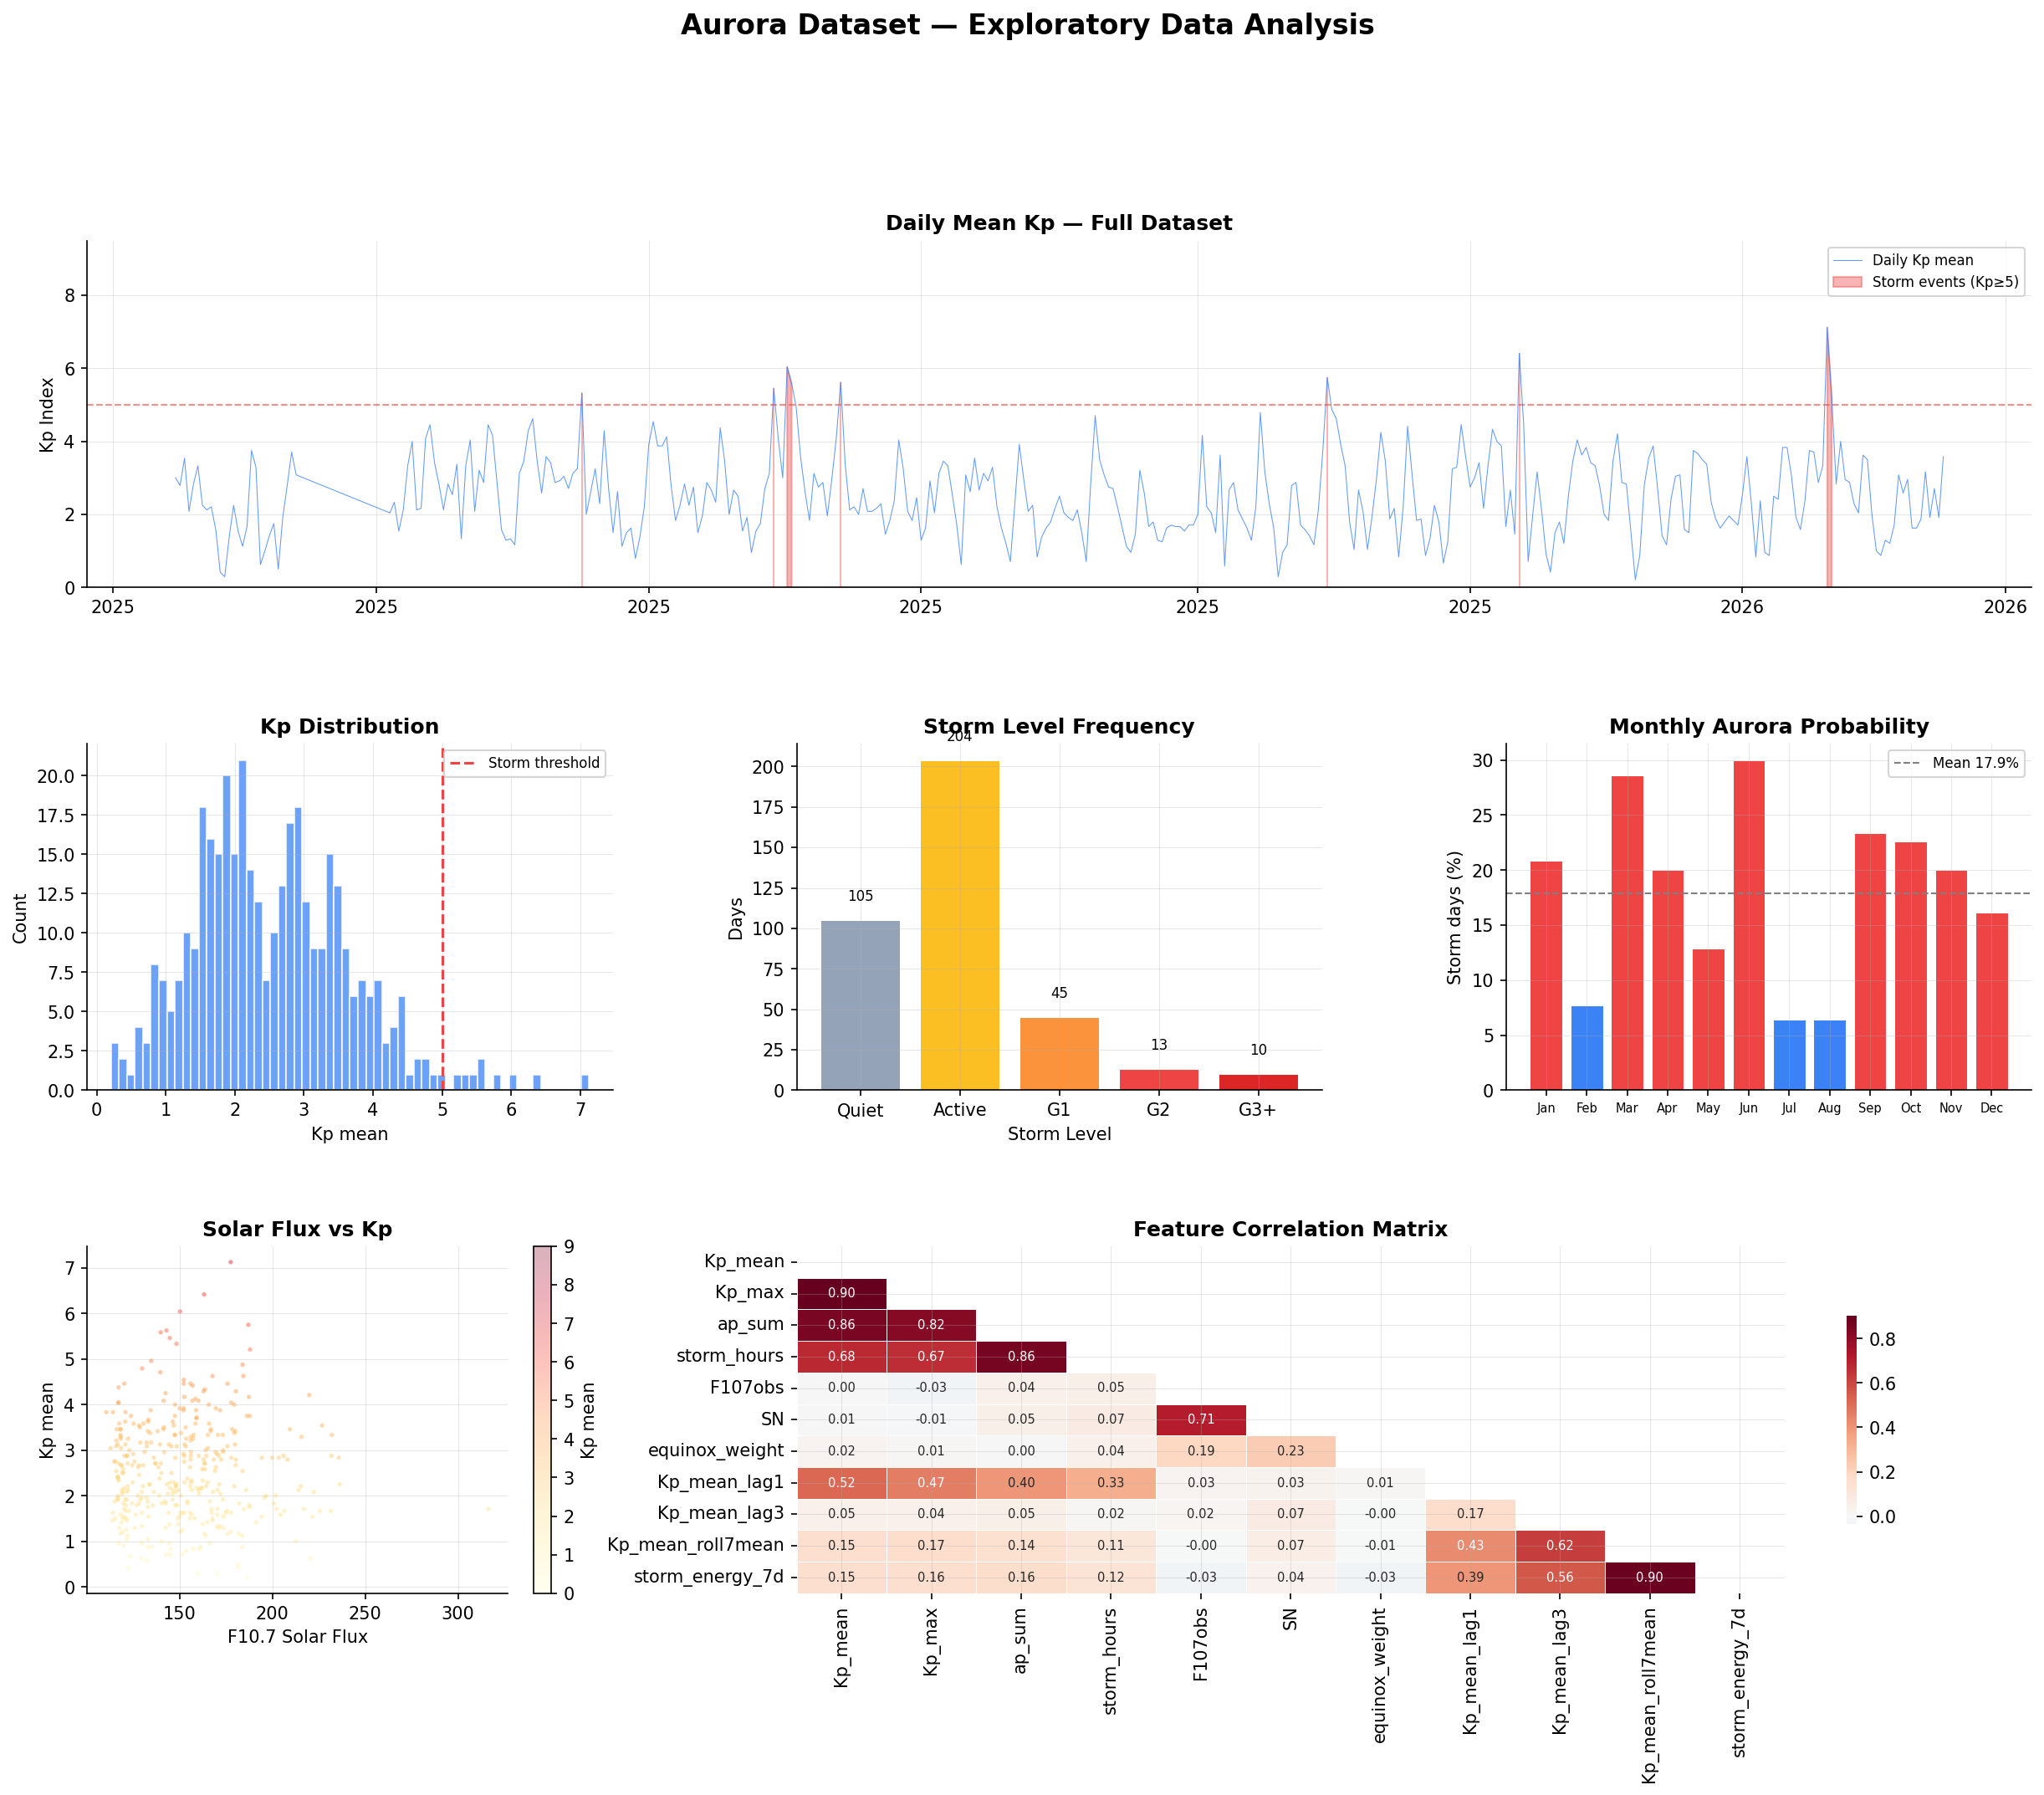

EDA saved ✓


In [8]:
# ── EDA: Kp distribution, storm events, solar cycle ───────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Kp mean over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['date'], df['Kp_mean'], lw=0.5, color='#3b82f6', alpha=0.8, label='Daily Kp mean')
ax1.fill_between(df['date'], df['Kp_mean'], where=df['Kp_mean'] >= 5,
                 color='#ef4444', alpha=0.4, label='Storm events (Kp≥5)')
ax1.axhline(5, color='#ef4444', lw=1, ls='--', alpha=0.6)
ax1.set_ylabel('Kp Index'); ax1.set_title('Daily Mean Kp — Full Dataset', fontweight='bold')
ax1.legend(fontsize=8); ax1.set_ylim(0, 9.5)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 2. Kp distribution
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(df['Kp_mean'], bins=60, color='#3b82f6', alpha=0.75, edgecolor='white', lw=0.3)
ax2.axvline(5, color='#ef4444', lw=1.5, ls='--', label='Storm threshold')
ax2.set_xlabel('Kp mean'); ax2.set_ylabel('Count')
ax2.set_title('Kp Distribution', fontweight='bold'); ax2.legend(fontsize=8)

# 3. Storm level breakdown
ax3 = fig.add_subplot(gs[1, 1])
level_counts = df['storm_level'].value_counts()
level_order  = ['Quiet', 'Active', 'G1', 'G2', 'G3+']
level_colors = ['#94a3b8', '#fbbf24', '#fb923c', '#ef4444', '#dc2626']
bars = ax3.bar(
    [l for l in level_order if l in level_counts],
    [level_counts.get(l, 0) for l in level_order if l in level_counts],
    color=[c for l, c in zip(level_order, level_colors) if l in level_counts],
    edgecolor='white', lw=0.5
)
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
ax3.set_xlabel('Storm Level'); ax3.set_ylabel('Days')
ax3.set_title('Storm Level Frequency', fontweight='bold')

# 4. Monthly aurora probability
ax4 = fig.add_subplot(gs[1, 2])
monthly = df.groupby('month')['aurora_event'].mean() * 100
months  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_c   = ['#ef4444' if v > 10 else '#3b82f6' for v in monthly.values]
ax4.bar(range(1, 13), monthly.values, color=bar_c, edgecolor='white', lw=0.5)
ax4.set_xticks(range(1, 13)); ax4.set_xticklabels(months, fontsize=7)
ax4.set_ylabel('Storm days (%)'); ax4.set_title('Monthly Aurora Probability', fontweight='bold')
ax4.axhline(monthly.mean(), color='gray', ls='--', lw=1, label=f'Mean {monthly.mean():.1f}%')
ax4.legend(fontsize=8)

# 5. F10.7 vs Kp scatter
ax5 = fig.add_subplot(gs[2, 0])
sc  = ax5.scatter(df['F107obs'], df['Kp_mean'], c=df['Kp_mean'],
                   cmap='YlOrRd', alpha=0.3, s=3, vmin=0, vmax=9)
plt.colorbar(sc, ax=ax5, label='Kp mean')
ax5.set_xlabel('F10.7 Solar Flux'); ax5.set_ylabel('Kp mean')
ax5.set_title('Solar Flux vs Kp', fontweight='bold')

# 6. Correlation heatmap (top features)
ax6 = fig.add_subplot(gs[2, 1:])
corr_cols = ['Kp_mean', 'Kp_max', 'ap_sum', 'storm_hours',
             'F107obs', 'SN', 'equinox_weight', 'Kp_mean_lag1',
             'Kp_mean_lag3', 'Kp_mean_roll7mean', 'storm_energy_7d']
corr_cols = [c for c in corr_cols if c in df.columns]
corr_mat  = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, ax=ax6, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.3,
            square=False, cbar_kws={'shrink': 0.6})
ax6.set_title('Feature Correlation Matrix', fontweight='bold')

fig.suptitle('Aurora Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.savefig(OUT_PLOTS / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA saved ✓')

## 6. Train / Validation / Test Split

In [9]:
# ── Define feature columns ─────────────────────────────────────────────────────
# Exclude raw Kp/ap slot columns (already summarised), date, target, labels
EXCLUDE_COLS = (
    ['date', TARGET_COL, 'aurora_event', 'storm_level']
    + [f'Kp{i}' for i in range(1, 9)]
    + [f'ap{i}' for i in range(1, 9)]
)
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f'Features used: {len(FEATURE_COLS)}')
print(', '.join(FEATURE_COLS[:20]), '...')

# ── Chronological split (no shuffling — time series!) ─────────────────────────
n        = len(df)
n_test   = int(n * TEST_SPLIT)
n_val    = int(n * VAL_SPLIT)
n_train  = n - n_test - n_val

df_train = df.iloc[:n_train].copy()
df_val   = df.iloc[n_train : n_train + n_val].copy()
df_test  = df.iloc[n_train + n_val :].copy()

X_train = df_train[FEATURE_COLS].values
y_train = df_train[TARGET_COL].values
X_val   = df_val[FEATURE_COLS].values
y_val   = df_val[TARGET_COL].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test[TARGET_COL].values

# For classification (aurora event detection)
y_train_cls = df_train['aurora_event'].values
y_val_cls   = df_val['aurora_event'].values
y_test_cls  = df_test['aurora_event'].values

print(f'\nSplit summary:')
print(f'  Train : {n_train:,} days  ({df_train["date"].iloc[0].date()} → {df_train["date"].iloc[-1].date()})')
print(f'  Val   : {n_val:,} days  ({df_val["date"].iloc[0].date()} → {df_val["date"].iloc[-1].date()})')
print(f'  Test  : {n_test:,} days  ({df_test["date"].iloc[0].date()} → {df_test["date"].iloc[-1].date()})')
print(f'\nStorm events in test set: {y_test_cls.sum()} / {len(y_test_cls)} ({y_test_cls.mean()*100:.1f}%)')

Features used: 189
Ap, SN, F107obs, F107adj, Kp_max, Kp_min, Kp_std, Kp_range, Kp_skew, ap_mean, ap_max, ap_sum, storm_hours, F107_smooth, SN_smooth, day_of_year, month, year, season_sin, season_cos ...

Split summary:
  Train : 265 days  (2025-01-15 → 2025-10-26)
  Val   : 56 days  (2025-10-27 → 2025-12-21)
  Test  : 56 days  (2025-12-22 → 2026-02-15)

Storm events in test set: 12 / 56 (21.4%)


## 7. Model Definitions

In [10]:
# ── XGBoost ────────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators      = 800,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    reg_alpha         = 0.1,    # L1
    reg_lambda        = 1.0,    # L2
    gamma             = 0.05,
    tree_method       = 'hist', # GPU if available: 'gpu_hist'
    random_state      = SEED,
    n_jobs            = -1,
    early_stopping_rounds = 50,
    eval_metric       = 'rmse',
    verbosity         = 0,
)

# ── LightGBM ──────────────────────────────────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    n_estimators      = 800,
    learning_rate     = 0.05,
    max_depth         = 6,
    num_leaves        = 63,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1,
)

# ── Random Forest ──────────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators   = 500,
    max_depth      = 20,
    min_samples_split = 4,
    min_samples_leaf  = 2,
    max_features   = 'sqrt',
    bootstrap      = True,
    oob_score      = True,    # out-of-bag estimate
    random_state   = SEED,
    n_jobs         = -1,
)

# ── Extra Trees ────────────────────────────────────────────────────────────────
et_model = ExtraTreesRegressor(
    n_estimators   = 500,
    max_depth      = 20,
    min_samples_split = 4,
    min_samples_leaf  = 2,
    max_features   = 'sqrt',
    bootstrap      = True,
    oob_score      = True,
    random_state   = SEED,
    n_jobs         = -1,
)

# ── Gradient Boosting (sklearn) ────────────────────────────────────────────────
gb_model = GradientBoostingRegressor(
    n_estimators   = 400,
    learning_rate  = 0.05,
    max_depth      = 5,
    subsample      = 0.8,
    min_samples_leaf = 5,
    random_state   = SEED,
)

# ── Model registry ────────────────────────────────────────────────────────────
MODEL_REGISTRY = {
    'XGBoost':           xgb_model,
    'LightGBM':          lgb_model,
    'Random Forest':     rf_model,
    'Extra Trees':       et_model,
    'Gradient Boosting': gb_model,
}

print('Models defined:')
for name in MODEL_REGISTRY:
    print(f'  • {name}')

Models defined:
  • XGBoost
  • LightGBM
  • Random Forest
  • Extra Trees
  • Gradient Boosting


## 8. Training

In [11]:
# ── Training loop ──────────────────────────────────────────────────────────────
trained_models  = {}
training_times  = {}

import time

for name, model in MODEL_REGISTRY.items():
    print(f"\n{'─'*55}")
    print(f"  Training: {name}")
    print(f"{'─'*55}")
    t0 = time.time()

    if name == 'XGBoost':
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=100
        )
        best_iter = model.best_iteration
        print(f'  Best iteration: {best_iter}')

    elif name == 'LightGBM':
        callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=callbacks
        )

    else:
        model.fit(X_train, y_train)
        if hasattr(model, 'oob_score_'):
            print(f'  OOB R² score: {model.oob_score_:.4f}')

    elapsed = time.time() - t0
    training_times[name] = elapsed
    trained_models[name] = model
    print(f'  ✓ Done in {elapsed:.1f}s')

    # Save model
    joblib.dump(model, OUT_MODELS / f'{name.replace(" ", "_")}.pkl')

print(f"\n{'='*55}")
print('All models trained and saved ✓')


───────────────────────────────────────────────────────
  Training: XGBoost
───────────────────────────────────────────────────────
[0]	validation_0-rmse:1.17209
[100]	validation_0-rmse:0.14944
[200]	validation_0-rmse:0.14168
[294]	validation_0-rmse:0.14140
  Best iteration: 244
  ✓ Done in 2.7s

───────────────────────────────────────────────────────
  Training: LightGBM
───────────────────────────────────────────────────────
[100]	valid_0's l2: 0.0713985
[200]	valid_0's l2: 0.0697257
[300]	valid_0's l2: 0.0678469
  ✓ Done in 1.9s

───────────────────────────────────────────────────────
  Training: Random Forest
───────────────────────────────────────────────────────
  OOB R² score: 0.9286
  ✓ Done in 2.1s

───────────────────────────────────────────────────────
  Training: Extra Trees
───────────────────────────────────────────────────────
  OOB R² score: 0.8826
  ✓ Done in 0.9s

───────────────────────────────────────────────────────
  Training: Gradient Boosting
──────────────────

## 9. Evaluation & Metrics

In [12]:
# ── Evaluation function ────────────────────────────────────────────────────────
def evaluate_model(model, X_te, y_te, name):
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    mape = np.mean(np.abs((y_te - y_pred) / (y_te + 1e-8))) * 100

    # Aurora detection (threshold at Kp >= 5)
    true_aurora = (y_te >= AURORA_KP_THRESHOLD).astype(int)
    pred_aurora = (y_pred >= AURORA_KP_THRESHOLD).astype(int)

    prec = precision_score(true_aurora, pred_aurora, zero_division=0)
    rec  = recall_score(true_aurora, pred_aurora, zero_division=0)
    f1   = f1_score(true_aurora, pred_aurora, zero_division=0)

    return {
        'y_pred': y_pred,
        'y_true': y_te,
        'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape,
        'precision': prec, 'recall': rec, 'f1': f1,
        'train_time': training_times[name],
    }


# ── Evaluate all models ────────────────────────────────────────────────────────
eval_results = {}
for name, model in trained_models.items():
    eval_results[name] = evaluate_model(model, X_test, y_test, name)

# ── Print summary table ────────────────────────────────────────────────────────
rows = []
for name, res in eval_results.items():
    rows.append({
        'Model':        name,
        'RMSE':         round(res['rmse'], 4),
        'MAE':          round(res['mae'], 4),
        'R²':           round(res['r2'], 4),
        'MAPE (%)':     round(res['mape'], 2),
        'Aurora Prec':  round(res['precision'], 3),
        'Aurora Rec':   round(res['recall'], 3),
        'Aurora F1':    round(res['f1'], 3),
        'Train Time(s)':round(res['train_time'], 1),
    })

metrics_df = pd.DataFrame(rows).sort_values('R²', ascending=False).reset_index(drop=True)
metrics_df.to_csv(OUT_DATA / 'model_metrics.csv', index=False)

print('\n=== Model Metrics (Test Set) ===')
print(metrics_df.to_string(index=False))
print('\nSaved → outputs/data/model_metrics.csv')


=== Model Metrics (Test Set) ===
            Model   RMSE    MAE     R²  MAPE (%)  Aurora Prec  Aurora Rec  Aurora F1  Train Time(s)
         LightGBM 0.3168 0.1610 0.9214      6.12        1.000         0.5      0.667            1.9
          XGBoost 0.3242 0.1345 0.9177      4.67        0.667         1.0      0.800            2.7
Gradient Boosting 0.3274 0.1240 0.9161      4.26        0.667         1.0      0.800            5.5
    Random Forest 0.3944 0.2394 0.8782     11.68        0.000         0.0      0.000            2.1
      Extra Trees 0.4809 0.3297 0.8189     16.73        0.000         0.0      0.000            0.9

Saved → outputs/data/model_metrics.csv


## 10. Plots — Predictions vs Actuals

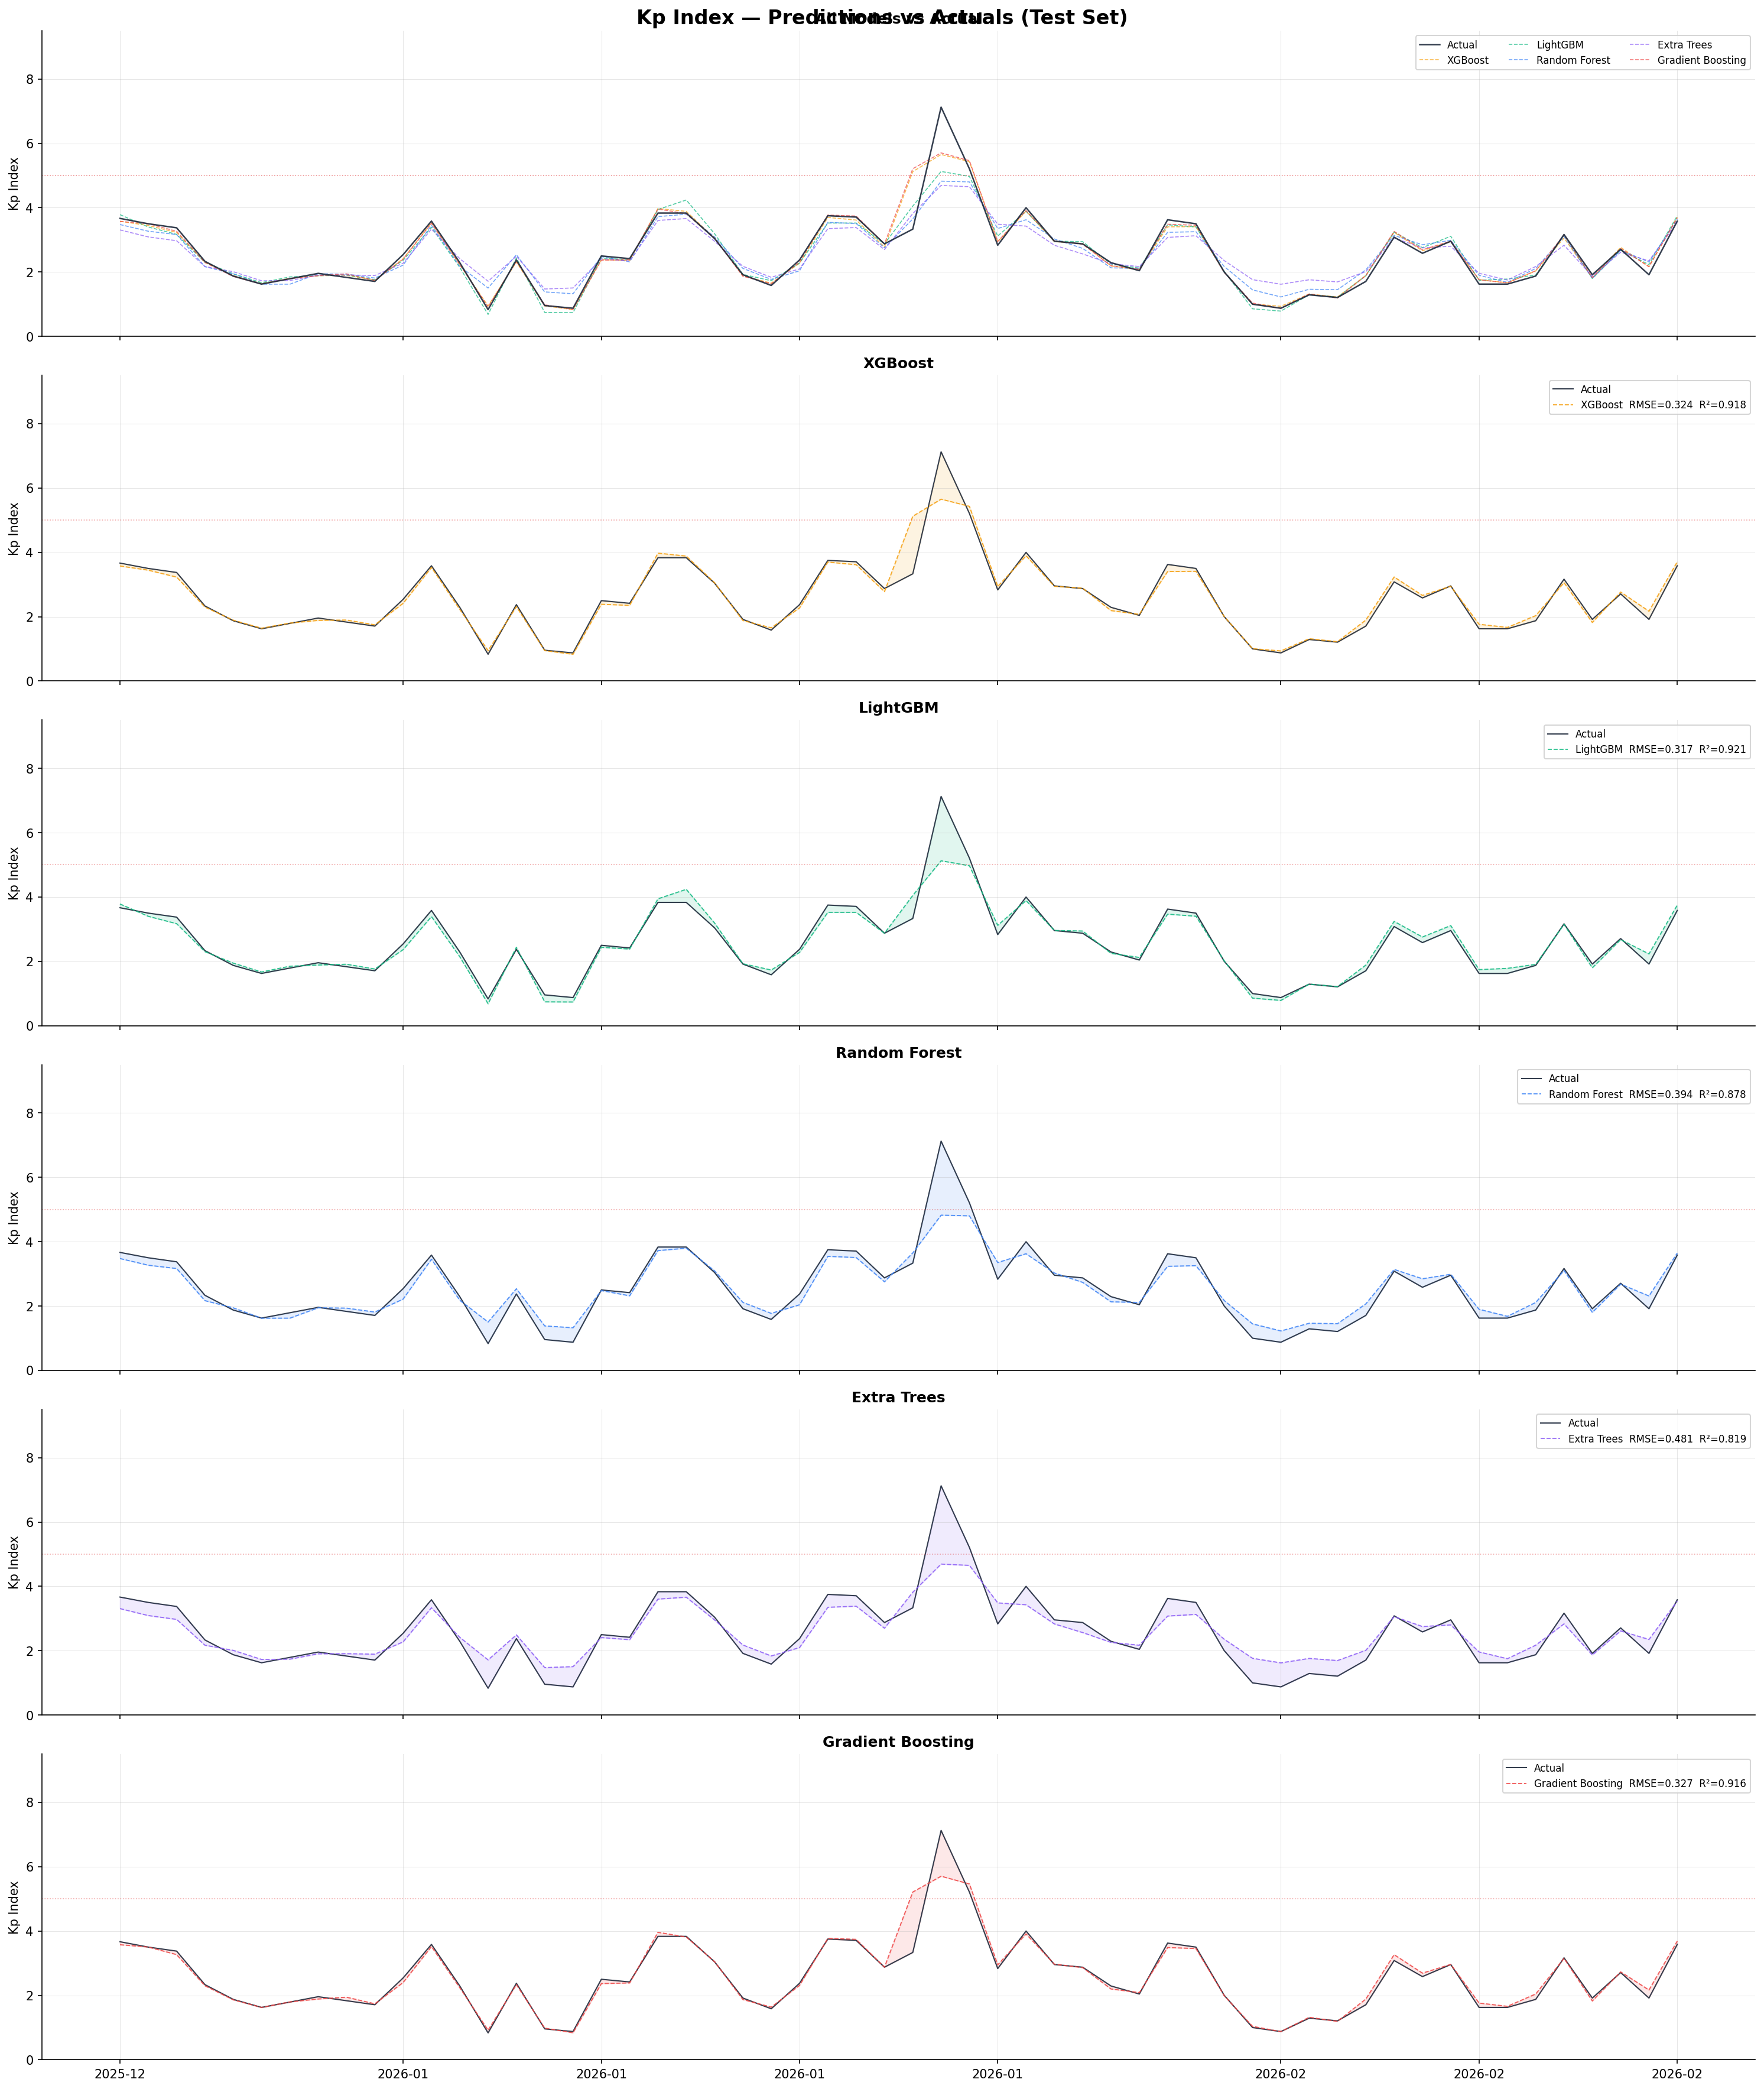

Saved → outputs/plots/predictions_vs_actuals.png


In [13]:
# ── Time-series: predictions vs actuals ───────────────────────────────────────
test_dates = df_test['date'].values

fig, axes = plt.subplots(len(eval_results) + 1, 1,
                          figsize=(20, 4 * (len(eval_results) + 1)),
                          sharex=True)
fig.suptitle('Kp Index — Predictions vs Actuals (Test Set)', fontsize=16, fontweight='bold')

# Top panel: all predictions overlaid on actuals
ax0 = axes[0]
ax0.plot(test_dates, y_test, lw=1.2, color=MODEL_COLORS['Actual'], label='Actual', alpha=0.9, zorder=10)
for name, res in eval_results.items():
    ax0.plot(test_dates, res['y_pred'], lw=0.8, color=MODEL_COLORS[name],
             label=name, alpha=0.7, ls='--')
ax0.axhline(AURORA_KP_THRESHOLD, color='#dc2626', lw=0.8, ls=':', alpha=0.5)
ax0.set_ylabel('Kp Index'); ax0.set_title('All Models vs Actual', fontweight='bold')
ax0.legend(fontsize=8, ncol=3); ax0.set_ylim(0, 9.5)

# One panel per model
for ax, (name, res) in zip(axes[1:], eval_results.items()):
    ax.plot(test_dates, res['y_true'], lw=1.0, color=MODEL_COLORS['Actual'],
            label='Actual', alpha=0.9)
    ax.plot(test_dates, res['y_pred'], lw=0.9, color=MODEL_COLORS[name],
            label=f'{name}  RMSE={res["rmse"]:.3f}  R²={res["r2"]:.3f}', ls='--', alpha=0.85)
    ax.fill_between(test_dates,
                    res['y_true'], res['y_pred'],
                    alpha=0.12, color=MODEL_COLORS[name])
    ax.axhline(AURORA_KP_THRESHOLD, color='#dc2626', lw=0.8, ls=':', alpha=0.4)
    ax.set_ylabel('Kp Index'); ax.legend(fontsize=8); ax.set_ylim(0, 9.5)
    ax.set_title(name, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig(OUT_PLOTS / 'predictions_vs_actuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/predictions_vs_actuals.png')

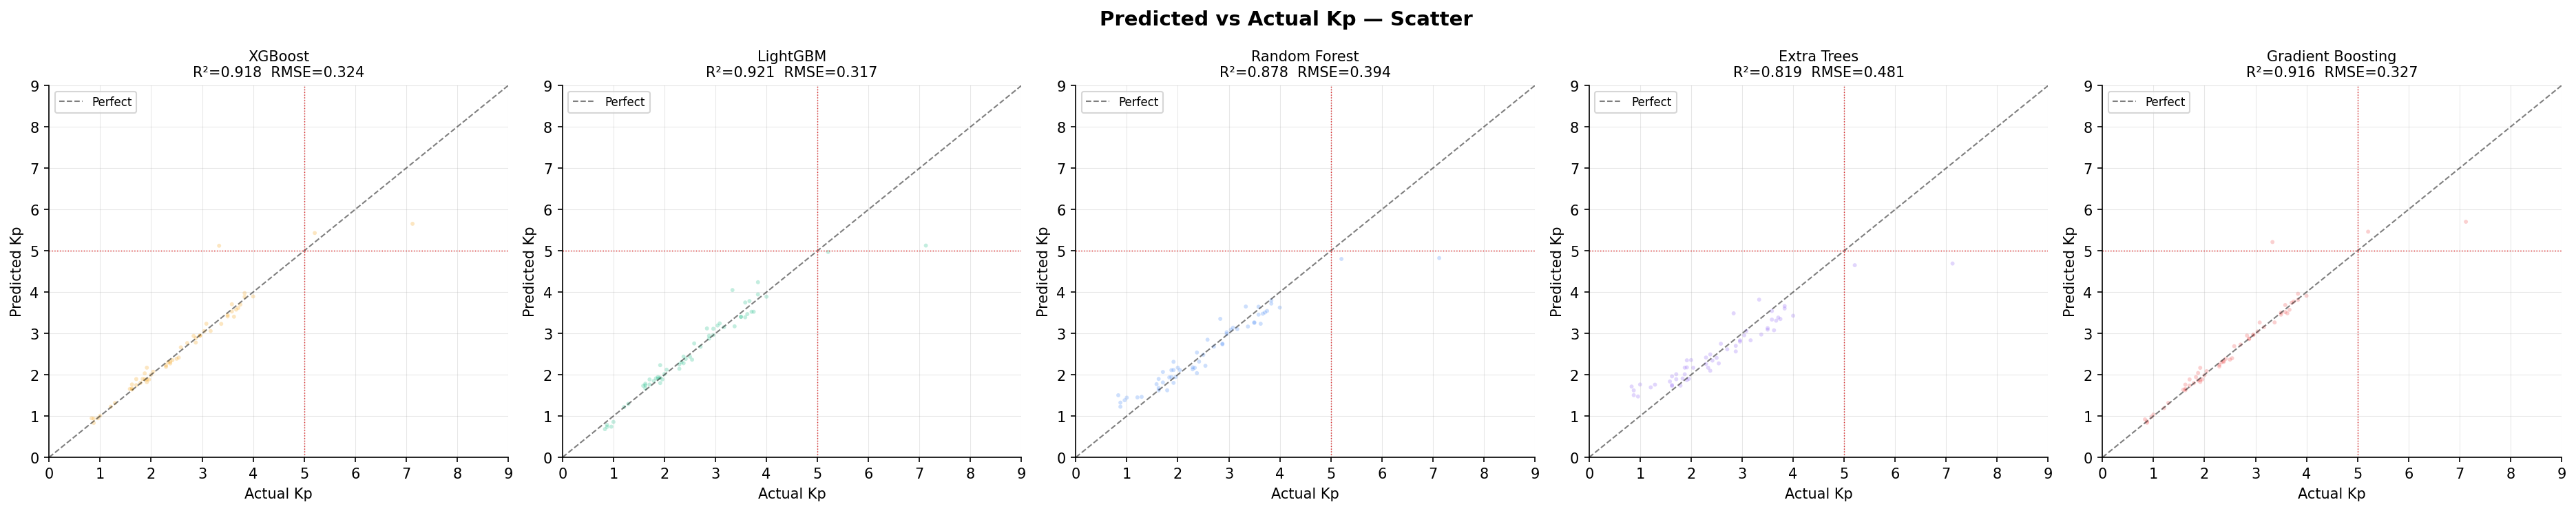

Saved → outputs/plots/scatter_predicted_vs_actual.png


In [14]:
# ── Scatter: predicted vs actual Kp ───────────────────────────────────────────
n_models = len(eval_results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
fig.suptitle('Predicted vs Actual Kp — Scatter', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, eval_results.items()):
    ax.scatter(res['y_true'], res['y_pred'], alpha=0.25, s=8,
               color=MODEL_COLORS[name], edgecolors='none')
    lims = [0, 9]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='Perfect')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Kp'); ax.set_ylabel('Predicted Kp')
    ax.set_title(f'{name}\nR²={res["r2"]:.3f}  RMSE={res["rmse"]:.3f}', fontsize=10)
    # Add reference lines for storm threshold
    ax.axvline(5, color='#dc2626', lw=0.7, ls=':'); ax.axhline(5, color='#dc2626', lw=0.7, ls=':')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_PLOTS / 'scatter_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/scatter_predicted_vs_actual.png')

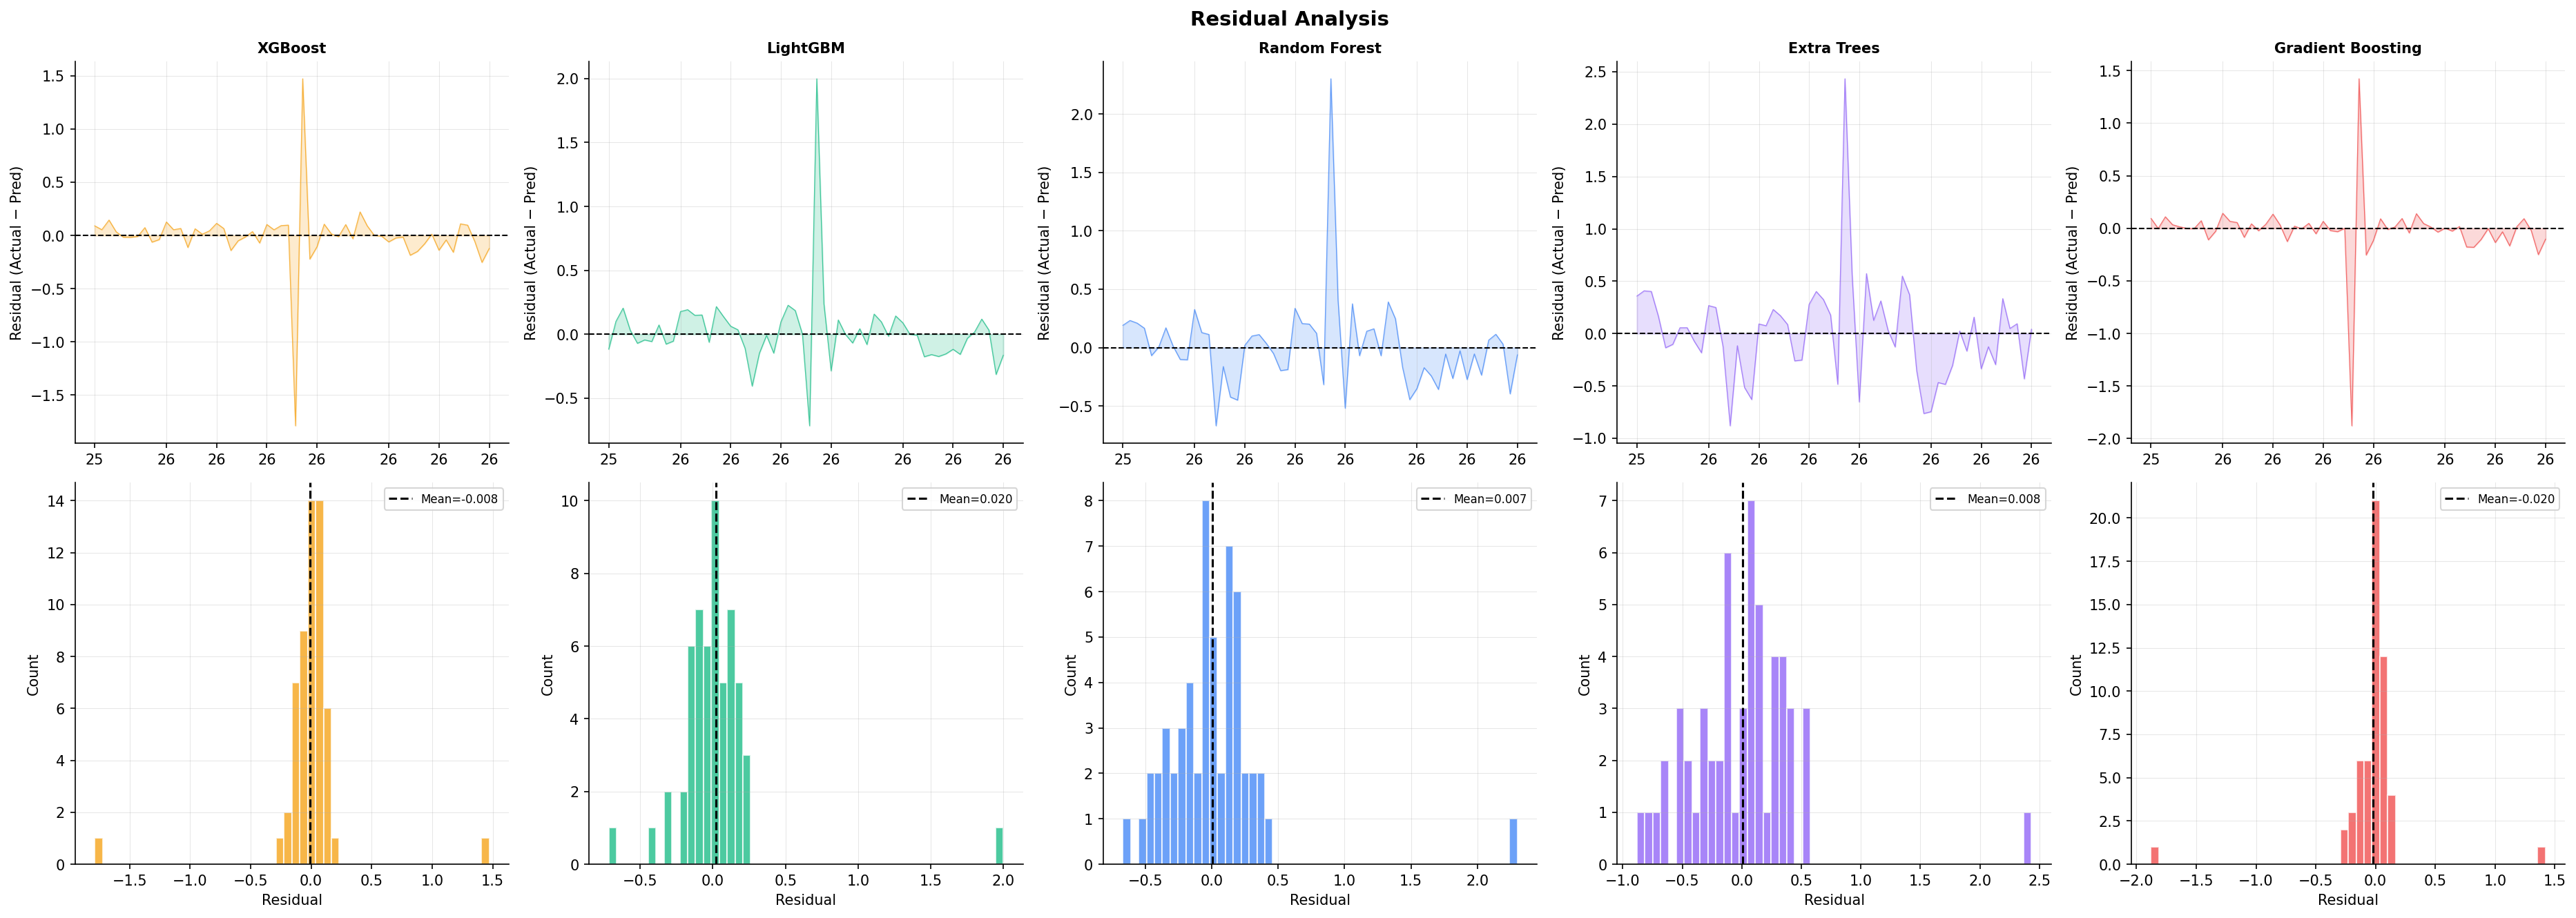

Saved → outputs/plots/residual_analysis.png


In [15]:
# ── Residual analysis ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 9))
fig.suptitle('Residual Analysis', fontsize=14, fontweight='bold')

for col, (name, res) in enumerate(eval_results.items()):
    residuals = res['y_true'] - res['y_pred']

    # Residuals over time
    ax_top = axes[0, col]
    ax_top.plot(test_dates, residuals, lw=0.6, color=MODEL_COLORS[name], alpha=0.7)
    ax_top.axhline(0, color='black', lw=1, ls='--')
    ax_top.fill_between(test_dates, residuals, 0, alpha=0.2, color=MODEL_COLORS[name])
    ax_top.set_title(name, fontweight='bold', fontsize=10)
    ax_top.set_ylabel('Residual (Actual − Pred)')
    ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%y'))

    # Residual distribution
    ax_bot = axes[1, col]
    ax_bot.hist(residuals, bins=50, color=MODEL_COLORS[name], alpha=0.75, edgecolor='white', lw=0.3)
    ax_bot.axvline(residuals.mean(), color='black', lw=1.5, ls='--',
                   label=f'Mean={residuals.mean():.3f}')
    ax_bot.set_xlabel('Residual'); ax_bot.set_ylabel('Count')
    ax_bot.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_PLOTS / 'residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/residual_analysis.png')

## 11. Metric Comparison Charts

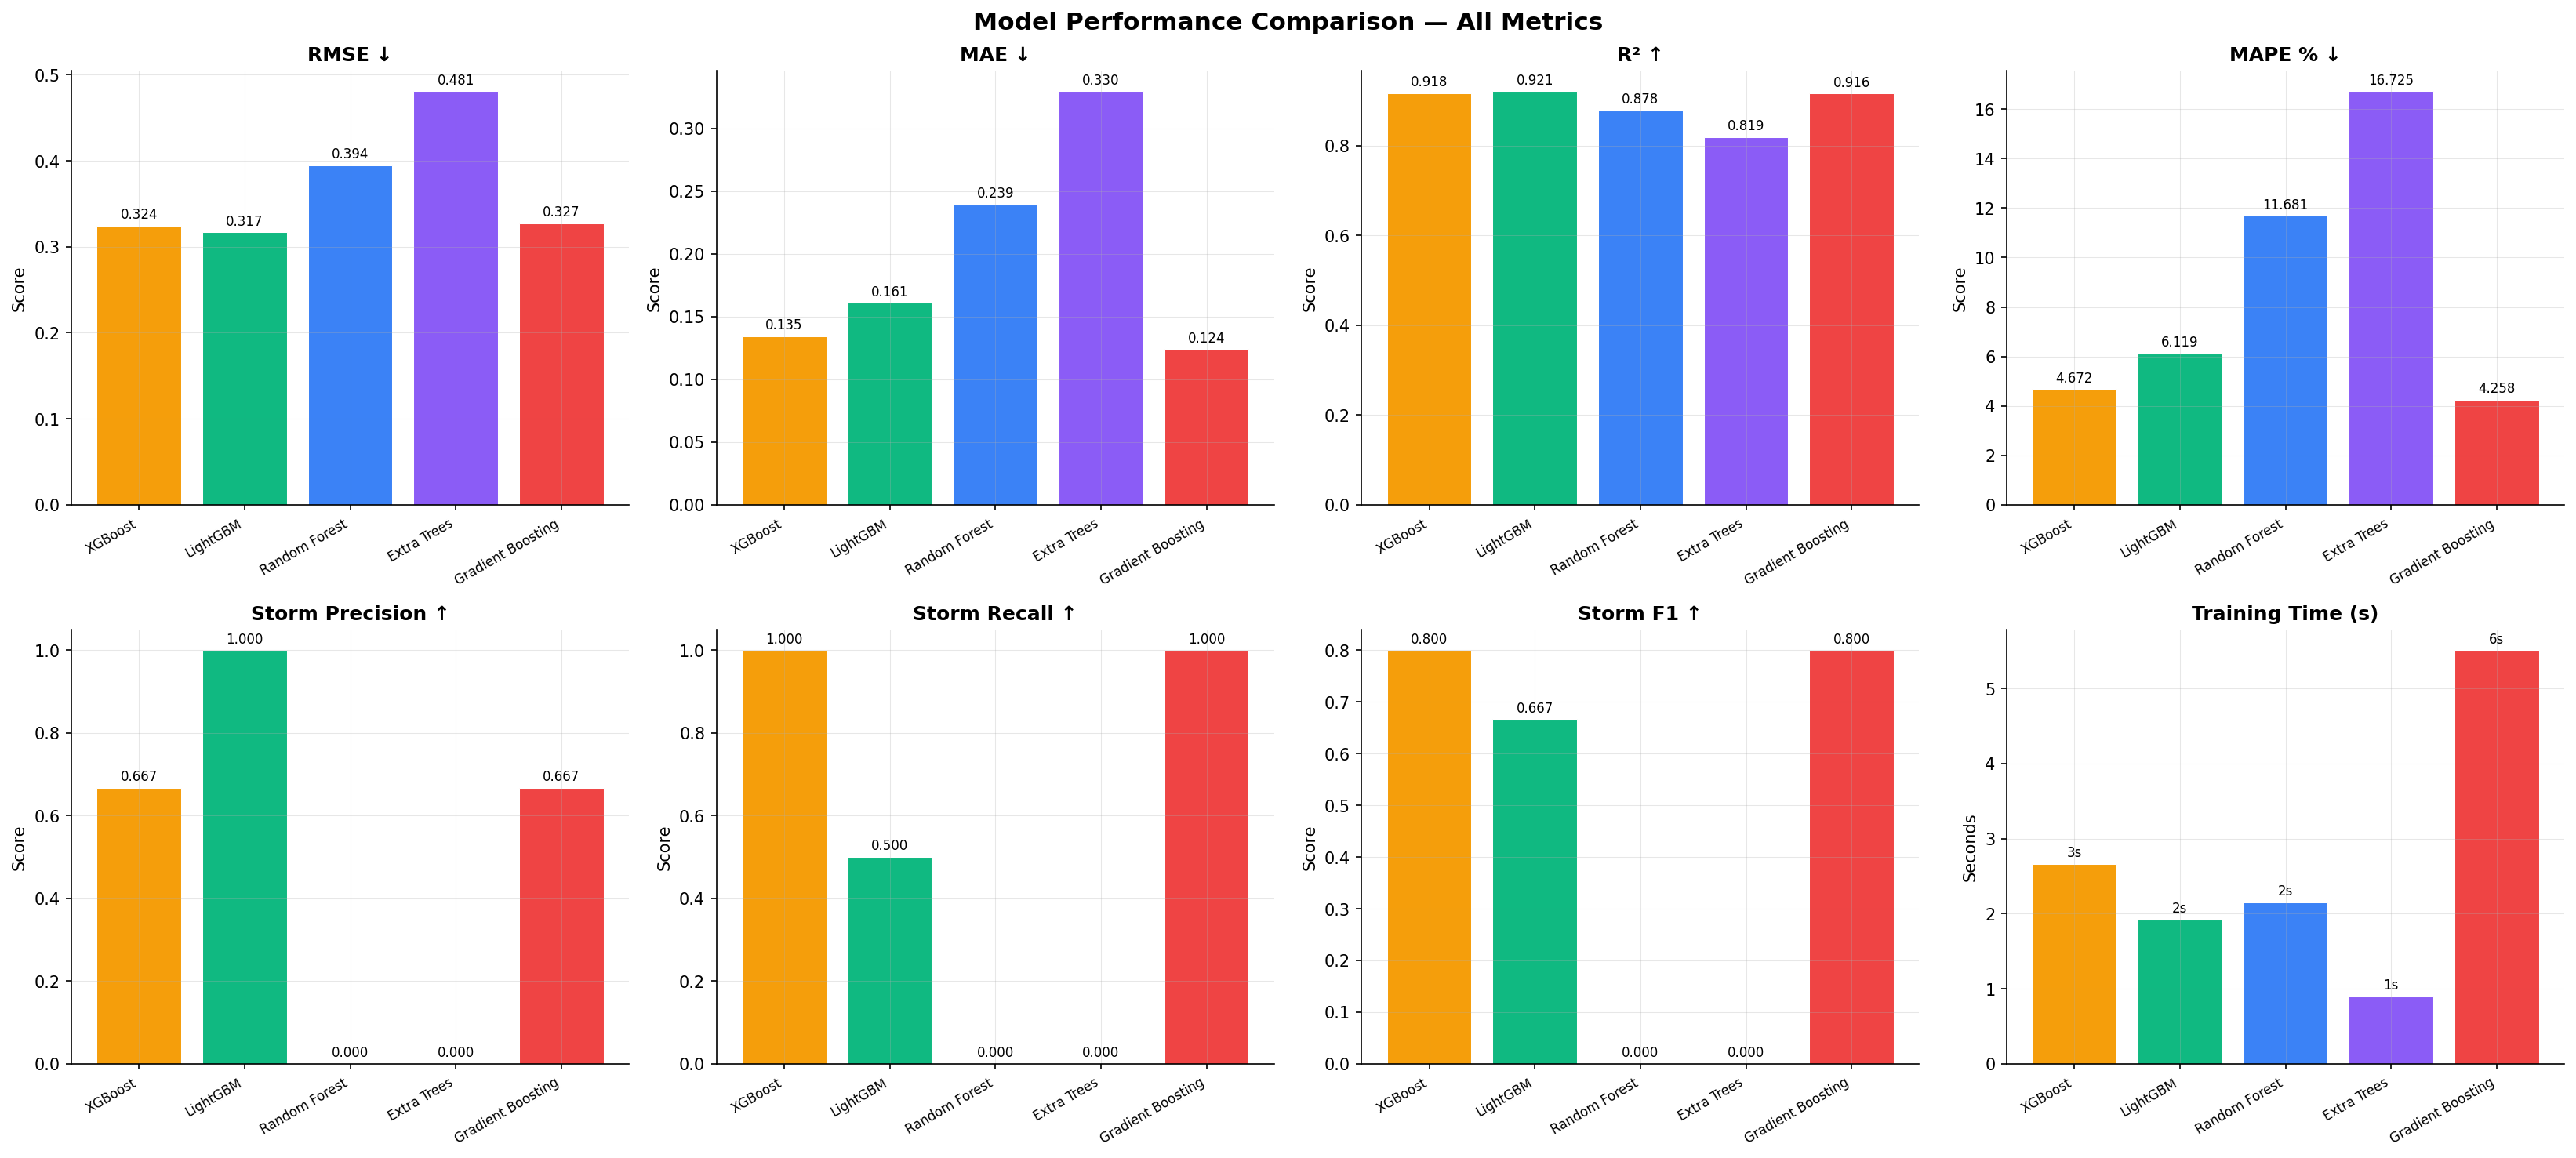

Saved → outputs/plots/model_comparison_metrics.png


In [16]:
# ── Model comparison bar charts ────────────────────────────────────────────────
metrics_plot = ['rmse', 'mae', 'r2', 'mape', 'precision', 'recall', 'f1']
metric_labels = ['RMSE ↓', 'MAE ↓', 'R² ↑', 'MAPE % ↓', 'Storm Precision ↑', 'Storm Recall ↑', 'Storm F1 ↑']
n_metrics = len(metrics_plot)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()
fig.suptitle('Model Performance Comparison — All Metrics', fontsize=15, fontweight='bold')

names  = list(eval_results.keys())
colors = [MODEL_COLORS[n] for n in names]

for i, (metric, label) in enumerate(zip(metrics_plot, metric_labels)):
    ax = axes[i]
    vals = [eval_results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='white', lw=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(label, fontweight='bold')
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Score')

# 8th panel: training time
ax = axes[7]
times = [eval_results[n]['train_time'] for n in names]
bars  = ax.bar(names, times, color=colors, edgecolor='white', lw=0.5)
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(times) * 0.01,
            f'{val:.0f}s', ha='center', va='bottom', fontsize=8)
ax.set_title('Training Time (s)', fontweight='bold')
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Seconds')

plt.tight_layout()
plt.savefig(OUT_PLOTS / 'model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/model_comparison_metrics.png')

## 12. Feature Importance

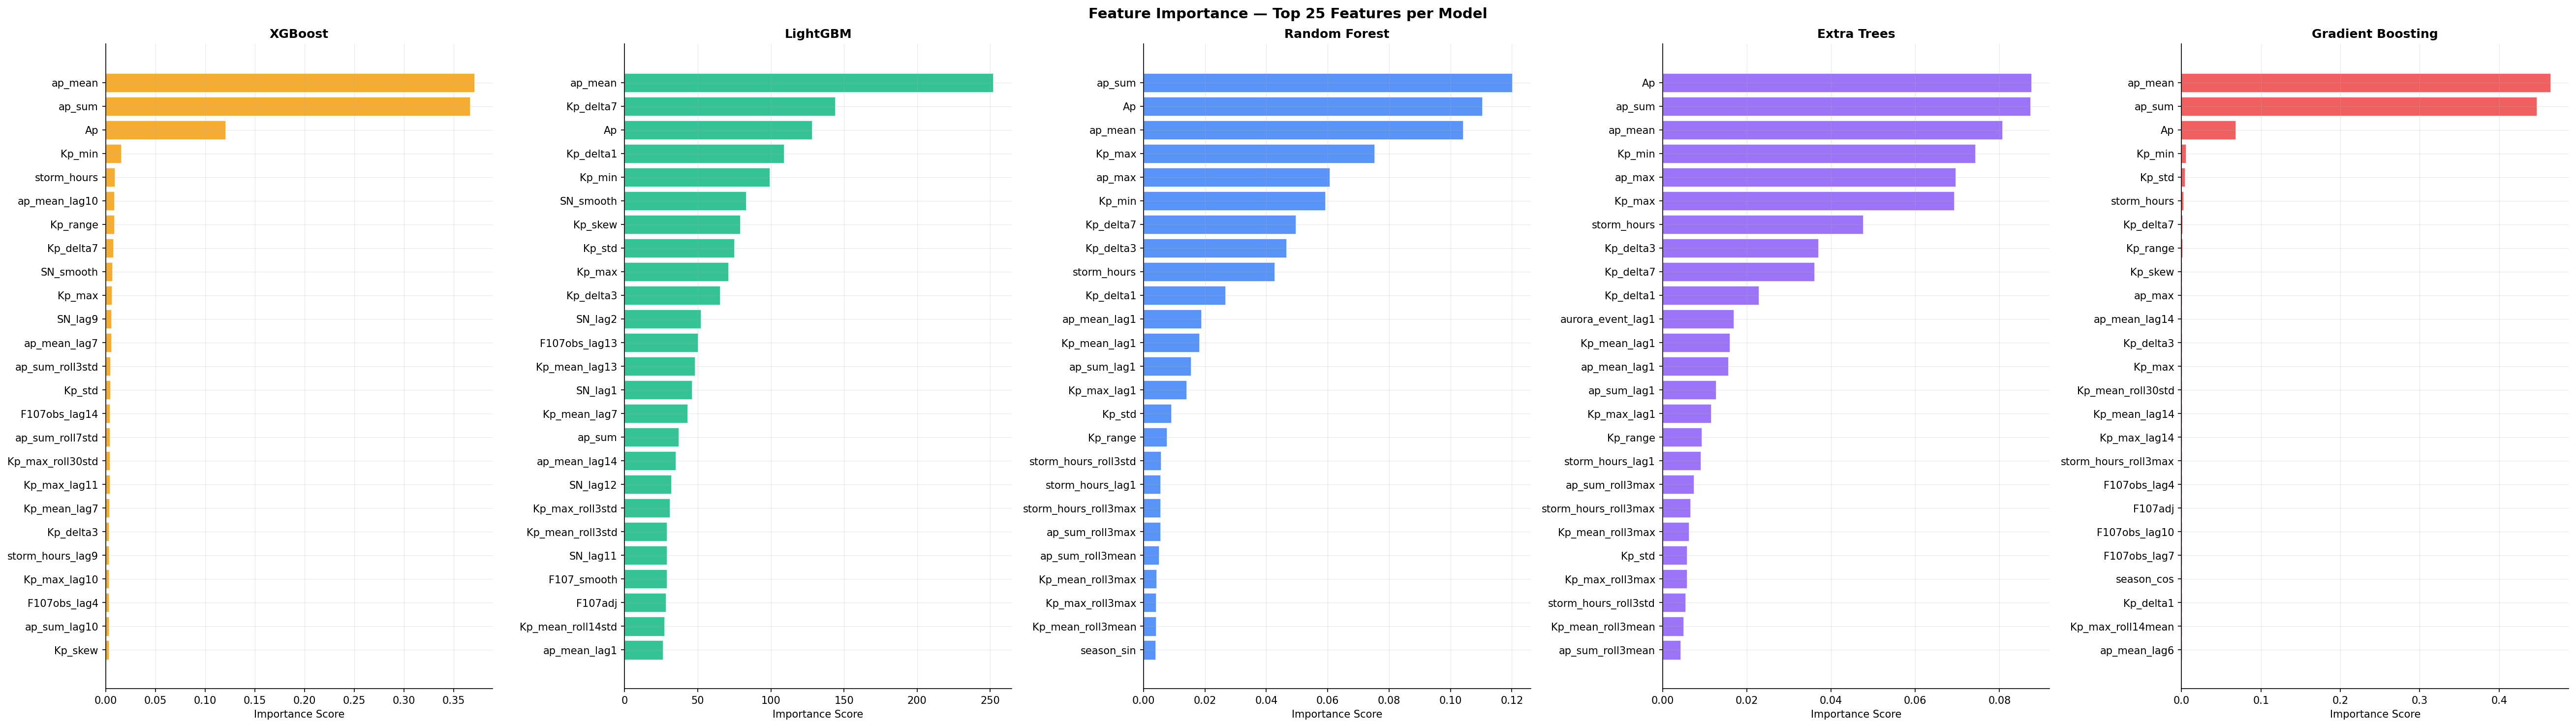

Saved → outputs/plots/feature_importance.png
Feature importance CSVs saved ✓


In [17]:
# ── Feature importance for all tree models ────────────────────────────────────
TOP_N = 25  # how many features to show

fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 10))
fig.suptitle(f'Feature Importance — Top {TOP_N} Features per Model', fontsize=14, fontweight='bold')

all_importances = {}

for ax, (name, model) in zip(axes, trained_models.items()):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        # Fallback: permutation importance on val set (slower)
        perm = permutation_importance(model, X_val, y_val, n_repeats=5, random_state=SEED)
        imp  = perm.importances_mean

    imp_series = pd.Series(imp, index=FEATURE_COLS).sort_values(ascending=False)
    all_importances[name] = imp_series
    top = imp_series.head(TOP_N)

    bars = ax.barh(top.index[::-1], top.values[::-1],
                   color=MODEL_COLORS[name], alpha=0.85, edgecolor='white', lw=0.3)
    ax.set_xlabel('Importance Score')
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_PLOTS / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/feature_importance.png')

# Save feature importance CSVs
for name, imp_series in all_importances.items():
    fname = f'feature_importance_{name.replace(" ", "_")}.csv'
    imp_series.reset_index().rename(columns={'index': 'Feature', 0: 'Importance'}).to_csv(
        OUT_DATA / fname, index=False)
print('Feature importance CSVs saved ✓')

Computing SHAP values for XGBoost (this may take ~1 min)...


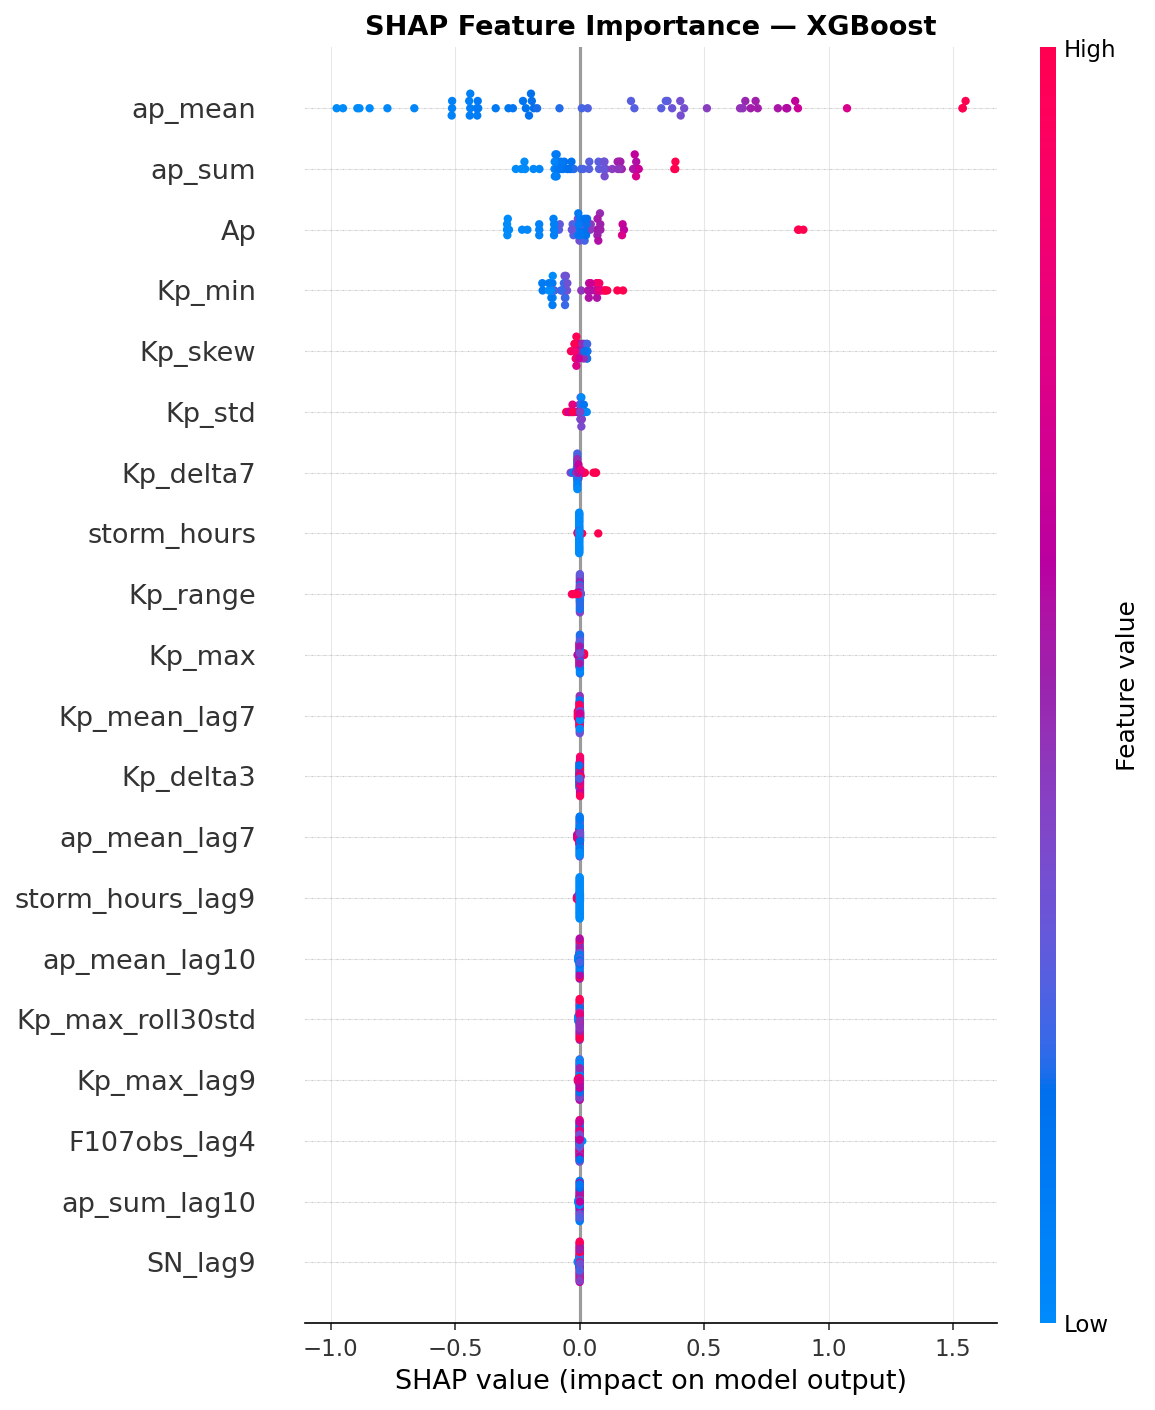

Saved → outputs/plots/shap_xgboost_summary.png


In [18]:
# ── SHAP values for XGBoost (most interpretable) ──────────────────────────────
print('Computing SHAP values for XGBoost (this may take ~1 min)...')

xgb_trained = trained_models['XGBoost']
explainer   = shap.TreeExplainer(xgb_trained)

# Use a sample for speed
sample_idx  = np.random.RandomState(SEED).choice(len(X_test), min(1000, len(X_test)), replace=False)
shap_values = explainer.shap_values(X_test[sample_idx])

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test[sample_idx],
                  feature_names=FEATURE_COLS,
                  max_display=20,
                  show=False)
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_PLOTS / 'shap_xgboost_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/shap_xgboost_summary.png')

## 13. Storm Event Detection Analysis

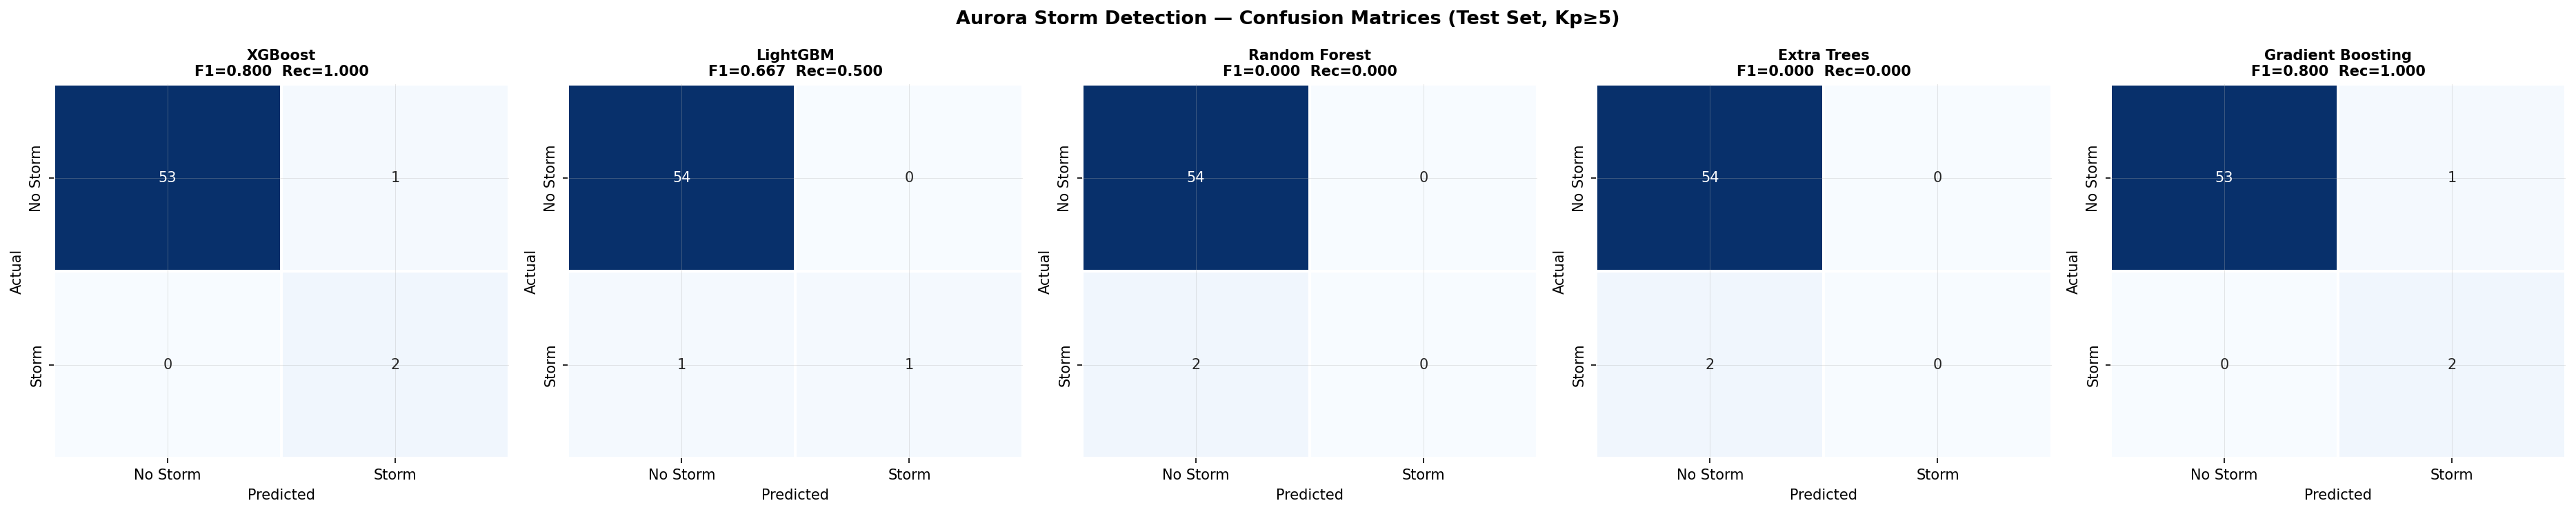

Saved → outputs/plots/confusion_matrices.png


In [19]:
# ── Confusion matrices for aurora storm detection ─────────────────────────────
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
fig.suptitle('Aurora Storm Detection — Confusion Matrices (Test Set, Kp≥5)', fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, eval_results.items()):
    y_true_bin = (res['y_true'] >= AURORA_KP_THRESHOLD).astype(int)
    y_pred_bin = (res['y_pred'] >= AURORA_KP_THRESHOLD).astype(int)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False, linewidths=1,
                xticklabels=['No Storm', 'Storm'],
                yticklabels=['No Storm', 'Storm'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{name}\nF1={res["f1"]:.3f}  Rec={res["recall"]:.3f}', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_PLOTS / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/confusion_matrices.png')

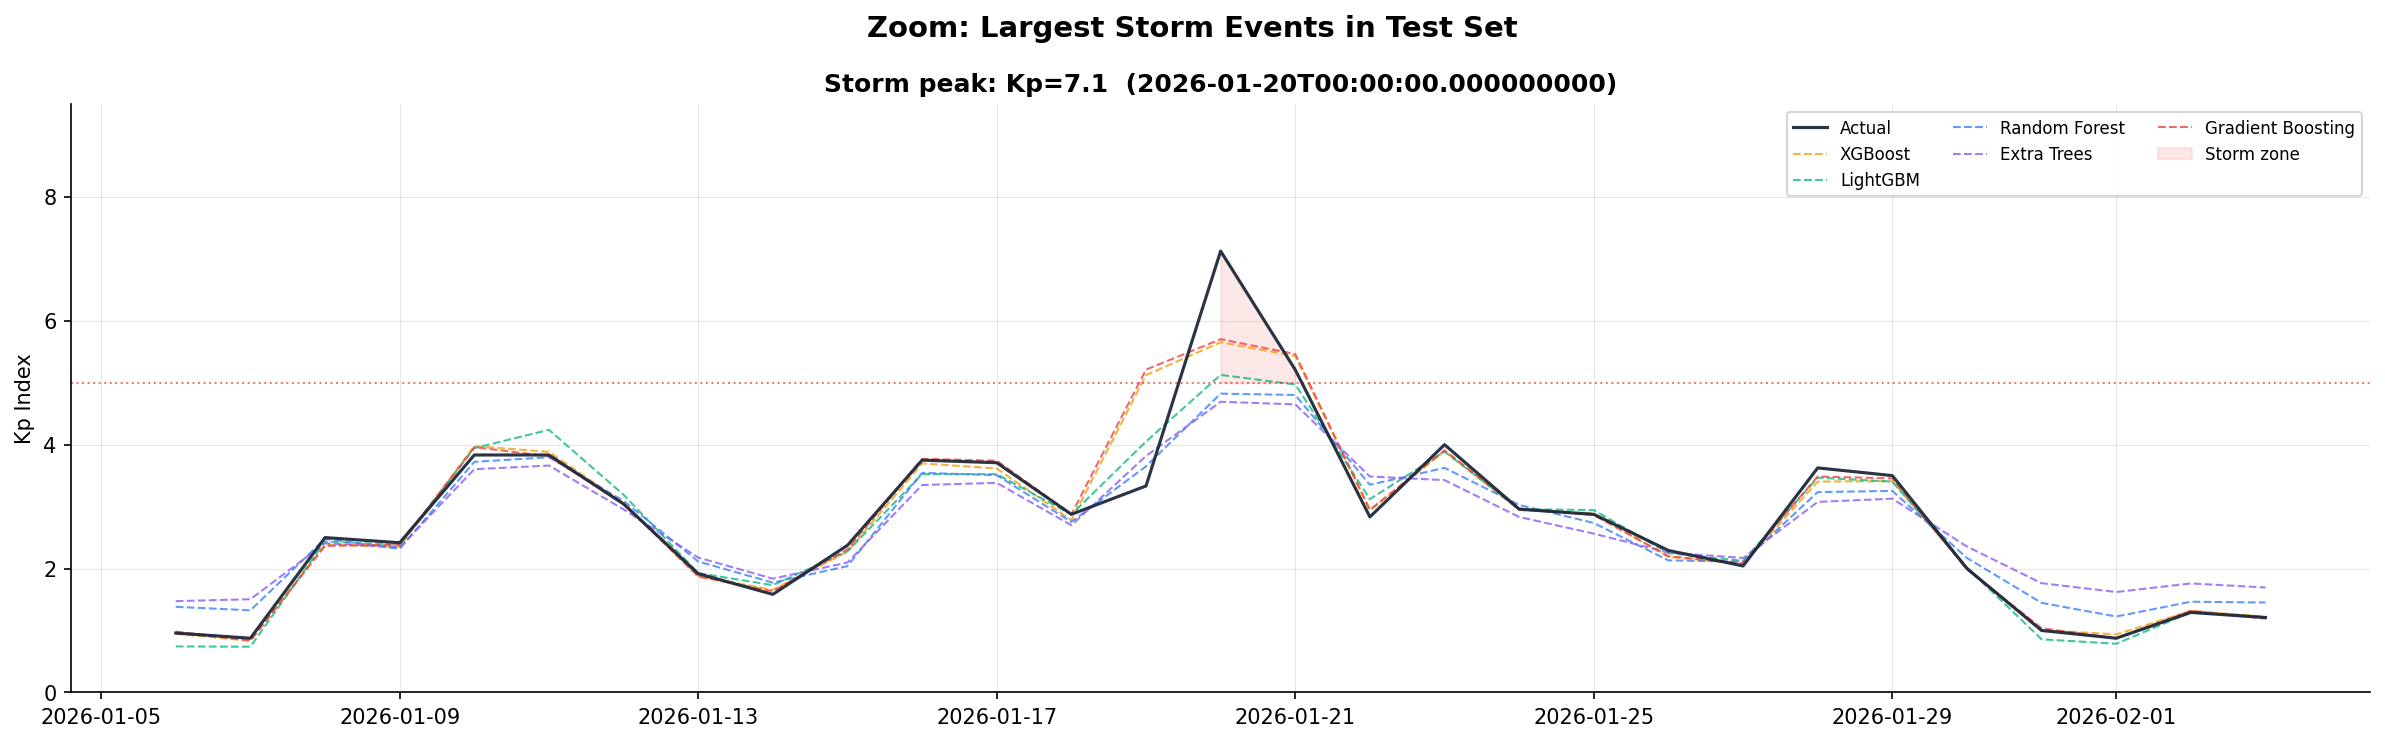

Saved → outputs/plots/storm_event_zoom.png


In [20]:
# ── Storm event zoom: worst & best storm events in test set ───────────────────
storm_mask = y_test >= AURORA_KP_THRESHOLD
storm_days  = np.where(storm_mask)[0]

if len(storm_days) > 0:
    # Find 3 largest storm clusters
    # Group consecutive days
    gaps = np.diff(storm_days)
    breaks = np.where(gaps > 3)[0] + 1
    clusters = np.split(storm_days, breaks)
    clusters = sorted(clusters, key=lambda c: y_test[c].max(), reverse=True)[:3]

    fig, axes = plt.subplots(len(clusters), 1, figsize=(16, 5 * len(clusters)))
    if len(clusters) == 1: axes = [axes]
    fig.suptitle('Zoom: Largest Storm Events in Test Set', fontsize=14, fontweight='bold')

    for ax, cluster in zip(axes, clusters):
        pad   = 14  # show 14 days either side
        start = max(0, cluster[0] - pad)
        end   = min(len(y_test), cluster[-1] + pad)
        idx   = slice(start, end)

        ax.plot(test_dates[idx], y_test[idx], lw=1.5, color='#1e293b',
                label='Actual', alpha=0.95, zorder=10)
        for name, res in eval_results.items():
            ax.plot(test_dates[idx], res['y_pred'][idx], lw=1.0,
                    color=MODEL_COLORS[name], label=name, ls='--', alpha=0.8)
        ax.axhline(AURORA_KP_THRESHOLD, color='#dc2626', lw=1, ls=':', alpha=0.6)
        ax.fill_between(test_dates[idx],
                        AURORA_KP_THRESHOLD, y_test[idx],
                        where=y_test[idx] >= AURORA_KP_THRESHOLD,
                        alpha=0.12, color='#ef4444', label='Storm zone')
        ax.set_ylabel('Kp Index'); ax.set_ylim(0, 9.5)
        ax.legend(fontsize=8, ncol=3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.set_title(f'Storm peak: Kp={y_test[cluster].max():.1f}  ({test_dates[cluster[0]]})', fontweight='bold')

    plt.tight_layout()
    plt.savefig(OUT_PLOTS / 'storm_event_zoom.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → outputs/plots/storm_event_zoom.png')
else:
    print('No storm events in test set — skipping zoom plot.')

## 14. Rolling Horizon Forecast

In [21]:
# ── 30-day forecast using the best model ──────────────────────────────────────
# For tree models: auto-regressive step — predict 1 day, append to lag features

def forecast_horizon(model, df_hist, feature_cols, target_col, forecast_days, lag_days):
    """
    Auto-regressive rolling forecast.
    At each step, the previous prediction is used to update lag columns.
    """
    df_fc = df_hist.copy()
    preds = []

    for step in range(forecast_days):
        # Build feature row from last available row
        last_row  = df_fc.iloc[-1:][feature_cols].values
        y_pred    = float(model.predict(last_row)[0])
        y_pred    = np.clip(y_pred, 0, 9)   # Kp is bounded [0, 9]
        preds.append(y_pred)

        # Create synthetic next row: shift lags forward
        next_date = df_fc['date'].iloc[-1] + pd.Timedelta(days=1)
        new_row   = df_fc.iloc[-1].copy()
        new_row['date'] = next_date
        new_row[target_col] = y_pred

        # Shift lag columns
        lag_targets = ['Kp_mean', 'Kp_max', 'ap_mean', 'ap_sum', 'storm_hours', 'aurora_event']
        for col in lag_targets:
            for lag in range(lag_days, 1, -1):
                lag_col      = f'{col}_lag{lag}'
                prev_lag_col = f'{col}_lag{lag-1}'
                if lag_col in new_row and prev_lag_col in new_row:
                    new_row[lag_col] = new_row[prev_lag_col]
            if f'{col}_lag1' in new_row:
                new_row[f'{col}_lag1'] = new_row[col] if col in new_row else y_pred

        # Update calendar features
        doy = next_date.timetuple().tm_yday
        new_row['day_of_year'] = doy
        new_row['month']       = next_date.month
        new_row['season_sin']  = np.sin(2 * np.pi * doy / 365.25)
        new_row['season_cos']  = np.cos(2 * np.pi * doy / 365.25)

        df_fc = pd.concat([df_fc, new_row.to_frame().T], ignore_index=True)

    return preds


# Best model by R²
best_model_name = metrics_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
print(f'Generating {FORECAST_DAYS}-day forecast using best model: {best_model_name}')

# Use all data up to test end as history
forecasts_all = {}
for name, model in trained_models.items():
    preds = forecast_horizon(model, df.copy(), FEATURE_COLS, TARGET_COL, FORECAST_DAYS, LAG_DAYS)
    forecasts_all[name] = preds
    print(f'  {name}: done')

# Dates for forecast period
last_date      = df['date'].max()
forecast_dates = [last_date + pd.Timedelta(days=i+1) for i in range(FORECAST_DAYS)]

# Ensemble forecast (mean across all models)
ens_fc    = np.mean([forecasts_all[n] for n in forecasts_all], axis=0)
ens_lower = np.percentile([forecasts_all[n] for n in forecasts_all], 10, axis=0)
ens_upper = np.percentile([forecasts_all[n] for n in forecasts_all], 90, axis=0)
aurora_prob = (np.array([forecasts_all[n] for n in forecasts_all]) >= AURORA_KP_THRESHOLD).mean(axis=0)

print(f'Ensemble forecast generated ✓')

Generating 30-day forecast using best model: LightGBM
  XGBoost: done
  LightGBM: done
  Random Forest: done
  Extra Trees: done
  Gradient Boosting: done
Ensemble forecast generated ✓


In [22]:
# ── Save forecast data ─────────────────────────────────────────────────────────
def kp_to_level(kp):
    if kp >= 7:   return 'G3+'
    elif kp >= 6: return 'G2'
    elif kp >= 5: return 'G1'
    elif kp >= 3: return 'Active'
    else:         return 'Quiet'

alert_df = pd.DataFrame({
    'Date':              [d.strftime('%Y-%m-%d') for d in forecast_dates],
    'Kp_Ensemble':       np.round(ens_fc, 2),
    'Kp_Lower_10pct':    np.round(ens_lower, 2),
    'Kp_Upper_90pct':    np.round(ens_upper, 2),
    'Aurora_Prob_pct':   np.round(aurora_prob * 100, 1),
    'Storm_Level':       [kp_to_level(k) for k in ens_fc],
})
for name in forecasts_all:
    alert_df[f'Kp_{name.replace(" ", "_")}'] = np.round(forecasts_all[name], 2)

alert_df.to_csv(OUT_DATA / 'forecast_30day.csv', index=False)
print('Forecast saved → outputs/data/forecast_30day.csv')
print(alert_df.to_string(index=False))

Forecast saved → outputs/data/forecast_30day.csv
      Date  Kp_Ensemble  Kp_Lower_10pct  Kp_Upper_90pct  Aurora_Prob_pct Storm_Level  Kp_XGBoost  Kp_LightGBM  Kp_Random_Forest  Kp_Extra_Trees  Kp_Gradient_Boosting
2026-02-16         3.67            3.58            3.73              0.0      Active        3.71         3.75              3.65            3.54                  3.69
2026-02-17         3.70            3.64            3.77              0.0      Active        3.71         3.80              3.71            3.59                  3.71
2026-02-18         3.69            3.61            3.76              0.0      Active        3.71         3.79              3.68            3.57                  3.70
2026-02-19         3.73            3.65            3.81              0.0      Active        3.70         3.84              3.76            3.62                  3.71
2026-02-20         3.72            3.63            3.80              0.0      Active        3.71         3.82            

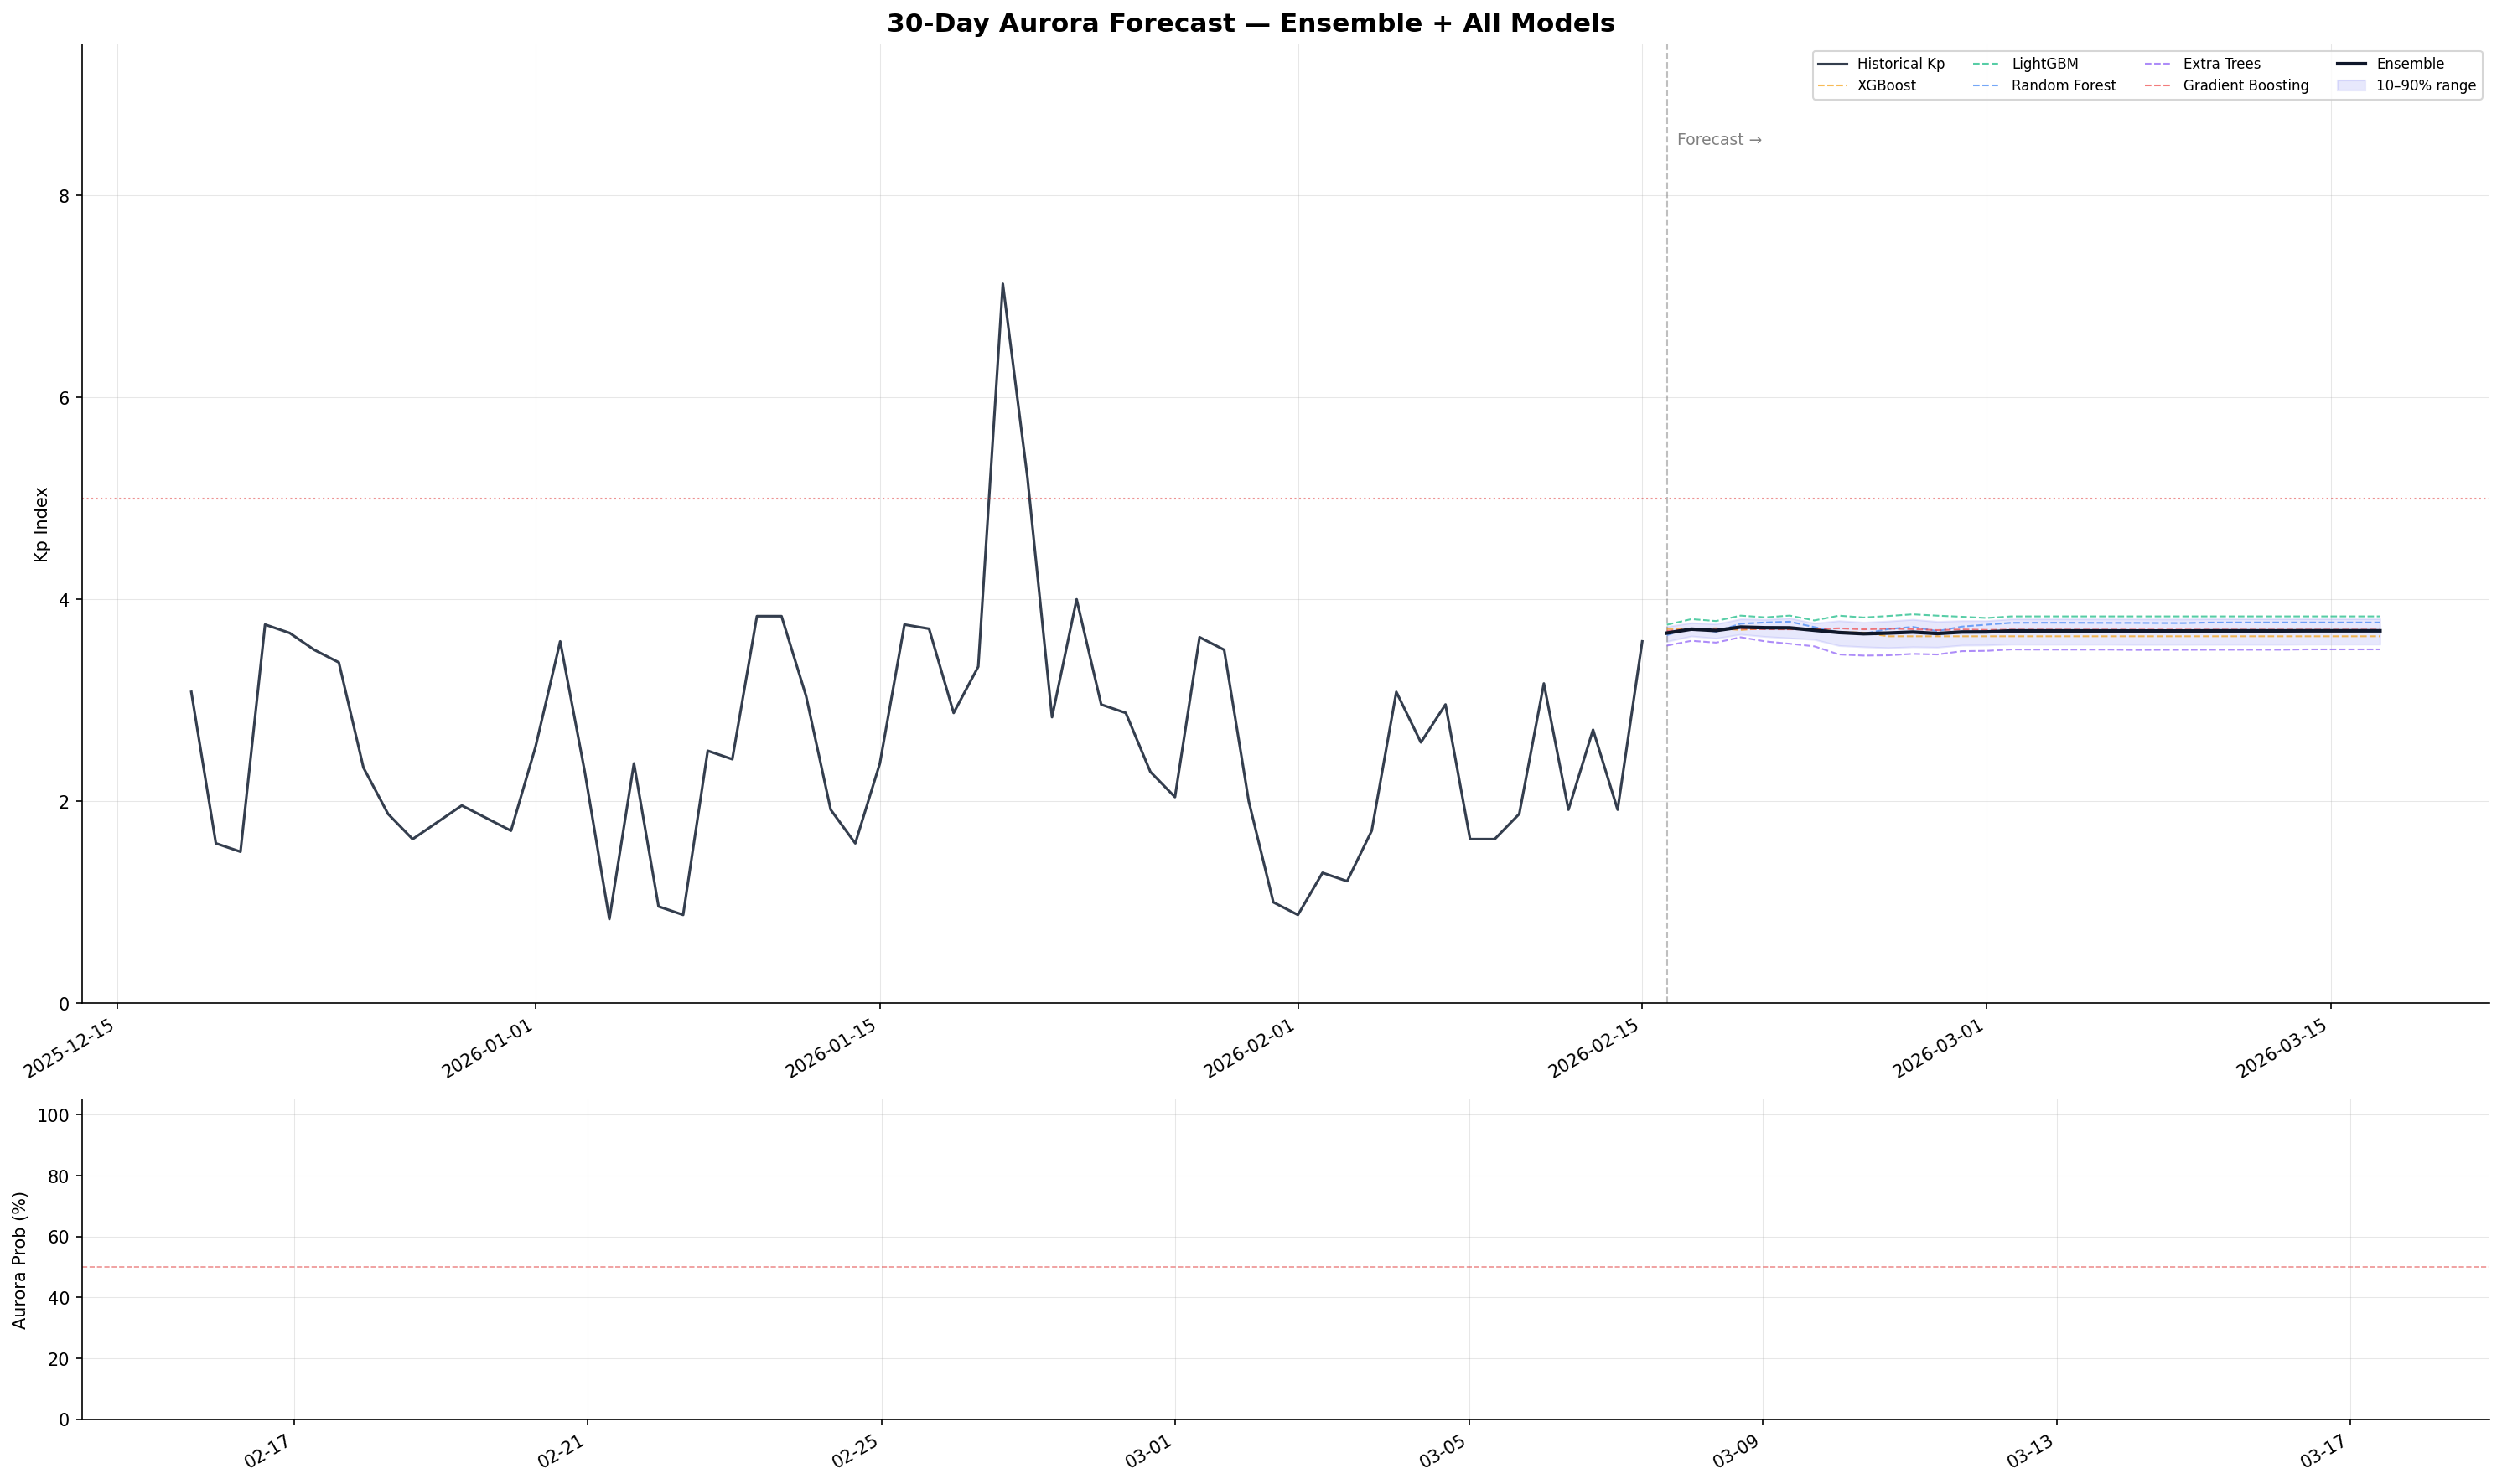

Saved → outputs/plots/forecast_30day.png


In [23]:
# ── Forecast plot ──────────────────────────────────────────────────────────────
# Show last 60 days of history + 30-day forecast
history_days = 60
hist_slice   = df.tail(history_days)

fig, axes = plt.subplots(2, 1, figsize=(20, 12), gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(f'{FORECAST_DAYS}-Day Aurora Forecast — Ensemble + All Models', fontsize=15, fontweight='bold')

ax = axes[0]
# Historical
ax.plot(hist_slice['date'], hist_slice['Kp_mean'], lw=1.5, color='#1e293b',
        label='Historical Kp', alpha=0.9)

# Vertical divider
ax.axvline(forecast_dates[0], color='gray', lw=1, ls='--', alpha=0.5)
ax.text(forecast_dates[0], 8.5, '  Forecast →', fontsize=9, color='gray')

# Individual model forecasts
for name, preds in forecasts_all.items():
    ax.plot(forecast_dates, preds, lw=1.0, color=MODEL_COLORS[name],
            label=name, ls='--', alpha=0.7)

# Ensemble + uncertainty band
ax.plot(forecast_dates, ens_fc, lw=2.0, color='#0f172a',
        label='Ensemble', zorder=10)
ax.fill_between(forecast_dates, ens_lower, ens_upper,
                alpha=0.15, color='#6366f1', label='10–90% range')

ax.axhline(AURORA_KP_THRESHOLD, color='#dc2626', lw=1, ls=':', alpha=0.5)
ax.set_ylabel('Kp Index'); ax.set_ylim(0, 9.5)
ax.legend(fontsize=8, ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Aurora probability bar chart
ax2 = axes[1]
prob_colors = ['#dc2626' if p > 0.5 else '#fb923c' if p > 0.25 else '#94a3b8'
               for p in aurora_prob]
ax2.bar(forecast_dates, aurora_prob * 100, color=prob_colors, edgecolor='white', lw=0.3)
ax2.axhline(50, color='#dc2626', lw=0.8, ls='--', alpha=0.5)
ax2.set_ylabel('Aurora Prob (%)')
ax2.set_ylim(0, 105)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(OUT_PLOTS / 'forecast_30day.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/forecast_30day.png')

## 15. Predictions vs Actuals — Full CSV Output

In [24]:
# ── Save all test-set predictions alongside actuals ────────────────────────────
pred_df = pd.DataFrame({'date': test_dates, 'Kp_actual': y_test})
for name, res in eval_results.items():
    pred_df[f'Kp_{name.replace(" ", "_")}'] = np.round(res['y_pred'], 3)

pred_df['ensemble_mean'] = pred_df[[c for c in pred_df.columns if c.startswith('Kp_') and c != 'Kp_actual']].mean(axis=1).round(3)

# Add storm level cols
pred_df['actual_storm_level'] = pred_df['Kp_actual'].apply(kp_to_level)
pred_df['ensemble_storm_level'] = pred_df['ensemble_mean'].apply(kp_to_level)

pred_df.to_csv(OUT_DATA / 'test_predictions_vs_actuals.csv', index=False)
print(f'Saved {len(pred_df):,} rows → outputs/data/test_predictions_vs_actuals.csv')
pred_df.head(10)

Saved 56 rows → outputs/data/test_predictions_vs_actuals.csv


,date,Kp_actual,Kp_XGBoost,Kp_LightGBM,Kp_Random_Forest,Kp_Extra_Trees,Kp_Gradient_Boosting,ensemble_mean,actual_storm_level,ensemble_storm_level
0,2025-12-22,3.666625,3.577,3.783,3.476,3.308,3.573,3.543,Active,Active
1,2025-12-23,3.499875,3.446,3.400,3.268,3.092,3.501,3.341,Active,Active
2,2025-12-24,3.375000,3.231,3.171,3.166,2.973,3.266,3.161,Active,Active
3,2025-12-25,2.333250,2.300,2.302,2.168,2.170,2.299,2.248,Quiet,Quiet
4,2025-12-26,1.874875,1.892,1.946,1.944,2.011,1.861,1.931,Quiet,Quiet
5,2025-12-27,1.625125,1.643,1.670,1.622,1.728,1.625,1.658,Quiet,Quiet
6,2025-12-28,1.791750,1.802,1.849,1.623,1.736,1.796,1.761,Quiet,Quiet
7,2025-12-29,1.958250,1.885,1.886,1.945,1.902,1.886,1.901,Quiet,Quiet
8,2025-12-30,1.833375,1.897,1.911,1.935,1.908,1.943,1.919,Quiet,Quiet
9,2025-12-31,1.708250,1.748,1.763,1.813,1.891,1.737,1.790,Quiet,Quiet


## 16. Cross-Validation — Model Stability Check

Running TimeSeriesSplit cross-validation (5 folds)...
  LightGBM: R² per fold = [0.791, 0.943, 0.967, 0.953, 0.951]  Mean=0.921 ± 0.065
  XGBoost: R² per fold = [0.9, 0.988, 0.993, 0.987, 0.942]  Mean=0.962 ± 0.036
  Gradient Boosting: R² per fold = [0.896, 0.983, 0.993, 0.985, 0.926]  Mean=0.957 ± 0.038


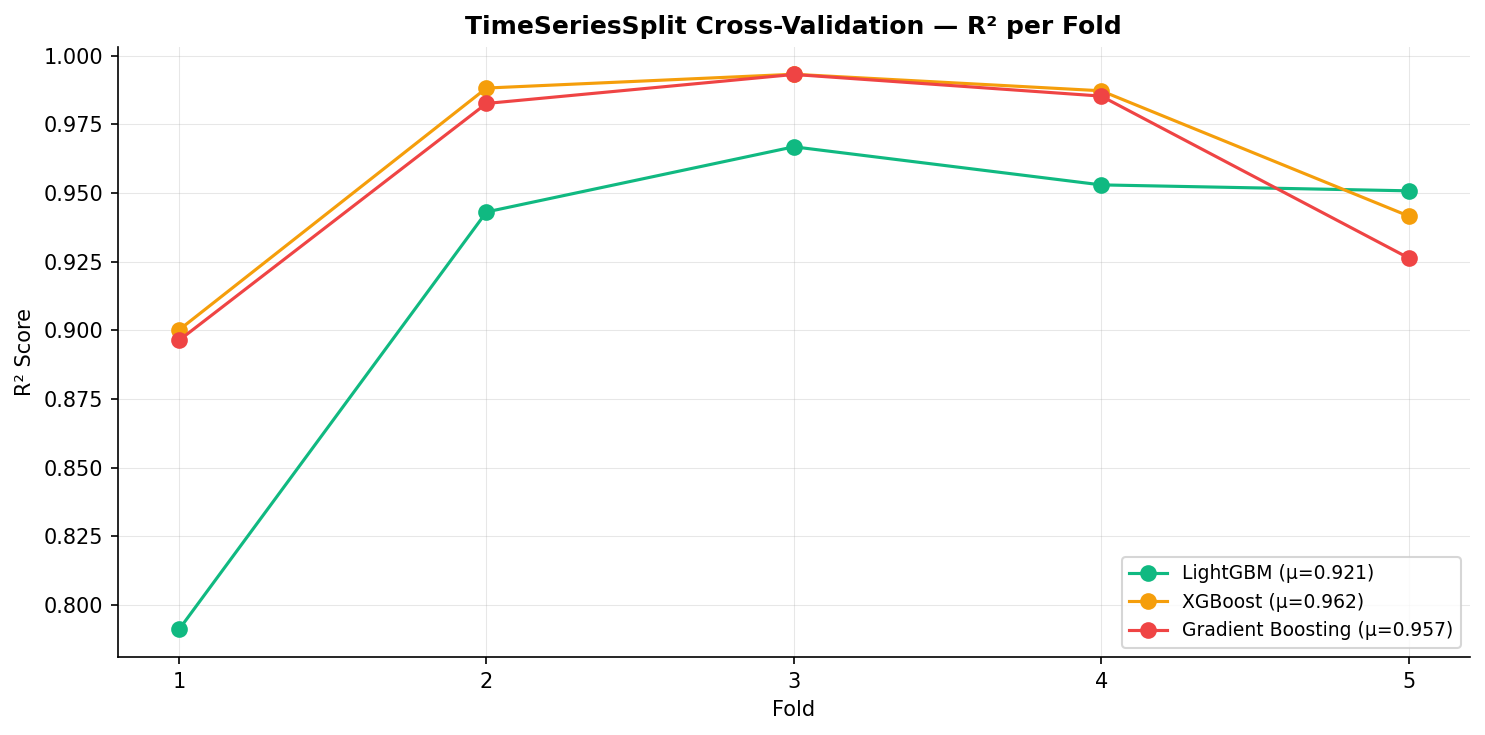

Saved → outputs/plots/cross_validation_r2.png
Saved → outputs/data/cross_validation_results.csv


In [25]:
# ── TimeSeriesSplit CV for top-3 models ────────────────────────────────────────
print('Running TimeSeriesSplit cross-validation (5 folds)...')
tscv = TimeSeriesSplit(n_splits=5)

X_full = df[FEATURE_COLS].values
y_full = df[TARGET_COL].values

cv_results = {}
top3 = metrics_df.head(3)['Model'].tolist()

for name in top3:
    model = trained_models[name]
    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_full)):
        X_tr, X_v = X_full[tr_idx], X_full[val_idx]
        y_tr, y_v = y_full[tr_idx], y_full[val_idx]

        if name == 'XGBoost':
            model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        elif name == 'LightGBM':
            cbs = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
            model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], callbacks=cbs)
        else:
            model.fit(X_tr, y_tr)

        y_pred = model.predict(X_v)
        fold_scores.append(r2_score(y_v, y_pred))

    cv_results[name] = fold_scores
    print(f'  {name}: R² per fold = {[round(s,3) for s in fold_scores]}  Mean={np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}')

# CV stability plot
fig, ax = plt.subplots(figsize=(10, 5))
for name, scores in cv_results.items():
    ax.plot(range(1, len(scores)+1), scores, 'o-',
            color=MODEL_COLORS[name], lw=1.5, ms=7, label=f'{name} (μ={np.mean(scores):.3f})')
ax.set_xlabel('Fold'); ax.set_ylabel('R² Score')
ax.set_title('TimeSeriesSplit Cross-Validation — R² per Fold', fontweight='bold')
ax.legend(fontsize=9); ax.set_xticks(range(1, 6))
plt.tight_layout()
plt.savefig(OUT_PLOTS / 'cross_validation_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/plots/cross_validation_r2.png')

cv_df = pd.DataFrame(cv_results).T
cv_df.columns = [f'fold_{i+1}' for i in range(5)]
cv_df['mean_r2'] = cv_df.mean(axis=1).round(4)
cv_df['std_r2']  = cv_df.std(axis=1).round(4)
cv_df.to_csv(OUT_DATA / 'cross_validation_results.csv')
print('Saved → outputs/data/cross_validation_results.csv')

## 17. Comparison Report — XGB/RF vs LSTM Baselines

In [26]:
# ── Paste your LSTM metrics here from your existing notebook ──────────────────
# (Load from aurora_model_metrics.csv if you saved it, or enter manually)
# ─────────────────────────────────────────────────────────────────────────────

# OPTION A: Load from existing CSV
LSTM_METRICS_CSV = None  # Set to path like '/content/drive/.../aurora_model_metrics.csv'

# OPTION B: Enter manually from your LSTM notebook's output
LSTM_MANUAL = [
    # {'Model': 'Stacked LSTM', 'RMSE': 0.85, 'MAE': 0.62, 'R²': 0.72, 'Aurora F1': 0.68},
    # {'Model': 'BiLSTM',       'RMSE': 0.82, 'MAE': 0.60, 'R²': 0.74, 'Aurora F1': 0.70},
    # {'Model': 'CNN-LSTM',     'RMSE': 0.80, 'MAE': 0.58, 'R²': 0.75, 'Aurora F1': 0.71},
    # {'Model': 'Attn-LSTM',    'RMSE': 0.78, 'MAE': 0.56, 'R²': 0.77, 'Aurora F1': 0.73},
]
# Uncomment the rows above and fill in your actual LSTM numbers.

if LSTM_METRICS_CSV and Path(LSTM_METRICS_CSV).exists():
    lstm_df = pd.read_csv(LSTM_METRICS_CSV)
    lstm_df['Model Family'] = 'LSTM'
    print(f'Loaded {len(lstm_df)} LSTM model metrics from CSV')
elif LSTM_MANUAL:
    lstm_df = pd.DataFrame(LSTM_MANUAL)
    lstm_df['Model Family'] = 'LSTM'
    print(f'Using {len(lstm_df)} manually entered LSTM metrics')
else:
    lstm_df = pd.DataFrame()
    print('ℹ️  No LSTM baseline provided. Add your metrics to LSTM_MANUAL above to enable comparison.')

# Combine with tree model results
tree_df = metrics_df.copy()
tree_df['Model Family'] = 'Tree'

if not lstm_df.empty:
    compare_cols = ['Model', 'Model Family', 'RMSE', 'MAE', 'R²', 'Aurora F1']
    # Align column names
    tree_subset  = tree_df[['Model', 'Model Family', 'RMSE', 'MAE', 'R²', 'Aurora F1']].copy()
    lstm_subset  = lstm_df[['Model', 'Model Family']].copy()
    for c in ['RMSE', 'MAE', 'R²', 'Aurora F1']:
        if c in lstm_df.columns:
            lstm_subset[c] = lstm_df[c]
    combined = pd.concat([tree_subset, lstm_subset], ignore_index=True)

    # Plot side-by-side grouped bar
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    fig.suptitle('Tree Models vs LSTM — Performance Comparison', fontsize=14, fontweight='bold')

    for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²', 'Aurora F1']):
        if metric not in combined.columns: continue
        grp   = combined.groupby('Model Family')[metric].mean()
        cols  = ['#f59e0b' if f == 'Tree' else '#6366f1' for f in grp.index]
        bars  = ax.bar(grp.index, grp.values, color=cols, edgecolor='white', lw=0.5)
        for bar, val in zip(bars, grp.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='500')
        ax.set_title(metric, fontweight='bold'); ax.set_ylabel('Score')

    plt.tight_layout()
    plt.savefig(OUT_PLOTS / 'comparison_tree_vs_lstm.png', dpi=150, bbox_inches='tight')
    plt.show()

    combined.to_csv(OUT_DATA / 'comparison_all_models.csv', index=False)
    print('Saved → outputs/plots/comparison_tree_vs_lstm.png')
    print('Saved → outputs/data/comparison_all_models.csv')

ℹ️  No LSTM baseline provided. Add your metrics to LSTM_MANUAL above to enable comparison.


## 18. Full Report — Text Summary

In [27]:
# ── Generate text report ───────────────────────────────────────────────────────
best_name = metrics_df.iloc[0]['Model']
best_r2   = metrics_df.iloc[0]['R²']
best_rmse = metrics_df.iloc[0]['RMSE']
best_f1   = metrics_df.iloc[0]['Aurora F1']

report_lines = [
    '=' * 70,
    'AURORA PREDICTION — TREE MODEL EVALUATION REPORT',
    f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}',
    '=' * 70,
    '',
    '── DATASET ──────────────────────────────────────────────────────────',
    f'  Date range    : {df["date"].min().date()} → {df["date"].max().date()}',
    f'  Total days    : {len(df):,}',
    f'  Features used : {len(FEATURE_COLS)}',
    f'  Train / Val / Test split: {n_train:,} / {n_val:,} / {n_test:,} days',
    f'  Storm events in test: {y_test_cls.sum()} ({y_test_cls.mean()*100:.1f}%)',
    '',
    '── METRICS SUMMARY (Test Set) ───────────────────────────────────────',
    metrics_df[['Model', 'RMSE', 'MAE', 'R²', 'MAPE (%)', 'Aurora F1']].to_string(index=False),
    '',
    '── BEST MODEL ───────────────────────────────────────────────────────',
    f'  {best_name}',
    f'  R²={best_r2:.4f}  RMSE={best_rmse:.4f}  Aurora F1={best_f1:.4f}',
    '',
    '── OUTPUT FILES ─────────────────────────────────────────────────────',
    '  data/model_metrics.csv                — test set metrics per model',
    '  data/test_predictions_vs_actuals.csv  — day-by-day predictions',
    '  data/forecast_30day.csv               — 30-day ensemble forecast',
    '  data/cross_validation_results.csv     — CV fold scores',
    '  data/feature_importance_*.csv         — importance per model',
    '  plots/predictions_vs_actuals.png      — time-series comparison',
    '  plots/scatter_predicted_vs_actual.png — scatter plots',
    '  plots/residual_analysis.png           — residuals',
    '  plots/model_comparison_metrics.png    — metric bar charts',
    '  plots/feature_importance.png          — top 25 features',
    '  plots/shap_xgboost_summary.png        — SHAP values (XGBoost)',
    '  plots/confusion_matrices.png          — storm detection CM',
    '  plots/storm_event_zoom.png            — storm event detail',
    '  plots/forecast_30day.png              — forecast + uncertainty',
    '  plots/cross_validation_r2.png         — CV stability',
    '  plots/comparison_tree_vs_lstm.png     — vs LSTM baselines',
    '  models/*.pkl                          — trained model files',
    '=' * 70,
]

report_text = '\n'.join(report_lines)
print(report_text)

with open(OUT_REPORTS / 'evaluation_report.txt', 'w') as f:
    f.write(report_text)
print('\nReport saved → outputs/reports/evaluation_report.txt')

AURORA PREDICTION — TREE MODEL EVALUATION REPORT
Generated: 2026-03-22 13:14

── DATASET ──────────────────────────────────────────────────────────
  Date range    : 2025-01-15 → 2026-02-15
  Total days    : 377
  Features used : 189
  Train / Val / Test split: 265 / 56 / 56 days
  Storm events in test: 12 (21.4%)

── METRICS SUMMARY (Test Set) ───────────────────────────────────────
            Model   RMSE    MAE     R²  MAPE (%)  Aurora F1
         LightGBM 0.3168 0.1610 0.9214      6.12      0.667
          XGBoost 0.3242 0.1345 0.9177      4.67      0.800
Gradient Boosting 0.3274 0.1240 0.9161      4.26      0.800
    Random Forest 0.3944 0.2394 0.8782     11.68      0.000
      Extra Trees 0.4809 0.3297 0.8189     16.73      0.000

── BEST MODEL ───────────────────────────────────────────────────────
  LightGBM
  R²=0.9214  RMSE=0.3168  Aurora F1=0.6670

── OUTPUT FILES ─────────────────────────────────────────────────────
  data/model_metrics.csv                — test set metric

## 19. Save All Outputs

In [28]:
# ── Final save summary ─────────────────────────────────────────────────────────
print('=== Final Output Summary ===')
for folder in [OUT_DATA, OUT_PLOTS, OUT_MODELS, OUT_REPORTS]:
    files = list(folder.glob('*'))
    print(f'\n{folder.name}/  ({len(files)} files)')
    for f in sorted(files):
        size_kb = f.stat().st_size / 1024
        print(f'  {f.name:<50} {size_kb:6.1f} KB')

print('\n✅ All outputs saved successfully!')
print(f'📁 Root output directory: {OUT_ROOT}')

=== Final Output Summary ===

data/  (9 files)
  cross_validation_results.csv                          0.4 KB
  feature_importance_Extra_Trees.csv                    6.6 KB
  feature_importance_Gradient_Boosting.csv              6.3 KB
  feature_importance_LightGBM.csv                       3.1 KB
  feature_importance_Random_Forest.csv                  6.7 KB
  feature_importance_XGBoost.csv                        3.6 KB
  forecast_30day.csv                                    1.9 KB
  model_metrics.csv                                     0.3 KB
  test_predictions_vs_actuals.csv                       4.0 KB

plots/  (11 files)
  confusion_matrices.png                               66.0 KB
  cross_validation_r2.png                              93.5 KB
  eda_overview.png                                    398.5 KB
  feature_importance.png                              316.4 KB
  forecast_30day.png                                  204.1 KB
  model_comparison_metrics.png                     